<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/projects/project_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafío de Clasificación — Predicción de Abandono de Clientes en ABC Multistate Bank


## Contexto y Objetivo

ABC Multistate Bank ha observado recientemente un número creciente de clientes que cierran sus cuentas. La pérdida de clientes no solo reduce los ingresos inmediatos, sino que también incrementa los costos de marketing necesarios para captar nuevos clientes. Para abordar este problema, el equipo de datos ha sido convocado para desarrollar un **modelo de clasificación** que prediga si un cliente tiene probabilidad de abandonar el banco (*churn*) en el corto plazo.

Su misión es actuar como **Experto en Datos** en ABC Bank y construir modelos predictivos que permitan al equipo de negocio identificar clientes en riesgo de abandono, de modo que el banco pueda tomar acciones preventivas a tiempo.





## Descripción del Dataset

El dataset contiene información de **10.000 clientes** del banco. La tarea consiste en predecir la variable `churn`, que indica si un cliente ha abandonado el banco (1) o no (0).

| Variable | Descripción |
|---|---|
| `customer_id` | Identificador único del cliente (no se usa en el modelado) |
| `credit_score` | Puntaje crediticio del cliente |
| `country` | País del cliente (France, Spain, Germany) |
| `gender` | Género (Male, Female) |
| `age` | Edad del cliente |
| `tenure` | Años de relación con el banco |
| `balance` | Saldo de la cuenta |
| `products_number` | Número de productos contratados |
| `credit_card` | Si el cliente tiene tarjeta de crédito (1/0) |
| `active_member` | Si el cliente es miembro activo (1/0) |
| `estimated_salary` | Salario anual estimado |
| `churn` | **Variable objetivo** (1 = abandonó, 0 = retenido) |



In [ ]:
import pandas as pd

# cargar datos
path = 'https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/projects/data/bank.csv'
df = pd.read_csv(path, sep="," )

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0




## Estructura del Proyecto

Deberá entregar un informe analítico completo que cubra tanto los aspectos técnicos como los de negocio. El notebook o informe debe incluir las siguientes secciones:


### 1. Introducción

- Presente el problema de negocio con sus propias palabras.
- Explique por qué predecir el *churn* es valioso para ABC Bank.
- Defina con claridad el objetivo del proyecto.



**Problema.** ABC Multistate Bank está perdiendo clientes que cierran sus cuentas (*churn*). Como retener a un cliente es más barato que captar uno nuevo, al banco le conviene saber **con anticipación** quién está en riesgo de irse para poder ofrecerle algo y evitar que se vaya.

**Objetivo.** Construir modelos de clasificación que, usando los datos de cada cliente, predigan si va a abandonar el banco (`churn = 1`) o no (`churn = 0`), e identificar qué factores influyen más en esa decisión.




### 2. Análisis Exploratorio de Datos (EDA)

Realice un análisis exploratorio riguroso para comprender los datos y extraer conclusiones relevantes.

El EDA debe incluir obligatoriamente:

- **Descripción general del dataset:** estructura, tipos de datos, duplicados y valores faltantes.
- **Análisis univariado:** distribuciones de variables numéricas y proporciones de variables categóricas.
- **Análisis bivariado:** relaciones entre los predictores y la variable `churn`.
- **Detección de valores atípicos:** identificación de valores extremos mediante IQR o z-scores.
- **Análisis de valores faltantes:** descripción de cantidad y ubicación, con hipótesis sobre sus posibles causas.

A continuación, **decida y justifique**:

- ¿Cómo tratará los valores atípicos? (p.ej., winsorización, eliminación, transformación)
- ¿Cómo imputará los datos faltantes? (p.ej., media/mediana, moda, métodos predictivos)
- ¿Hay variables que deban eliminarse o transformarse?



> Descripción general del dataset



In [ ]:
df.dtypes

,0
customer_id,int64
credit_score,int64
country,object
gender,object
age,int64
tenure,int64
balance,float64
products_number,int64
credit_card,int64
active_member,int64


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Descripción general del dataset
print("Filas y columnas:", df.shape)
print("Filas duplicadas:", df.duplicated().sum())
print("\nValores faltantes por columna:")
print(df.isnull().sum())


Filas y columnas: (10000, 12)
Filas duplicadas: 0

Valores faltantes por columna:
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


Diagnóstico de calidad de datos

Antes de proceder con el análisis descriptivo y estadístico, realizamos una auditoría de la calidad de la base de datos para asegurar la integridad de las conclusiones estratégicas. Los hallazgos principales son:

*   **Valores Duplicados:** `0%`. No se detectaron registros repetidos en la base de datos, lo que garantiza que cada observación representa un evento/cliente único y evita sesgos por sobre-representación.
*   **Datos Faltantes (Missing Values):** `0%`. Todas las variables cuentan con el 100% de sus registros completos. Al no existir sesgo de selección por pérdida de datos, no es necesario aplicar técnicas de imputación (como rellenar con la media o mediana), manteniendo la distribución original de las variables intacta.

> **Conclusión de Calidad:** La base de datos se encuentra completamente limpia y estructurada. Presenta una consistencia interna óptima para avanzar con confianza hacia el análisis estadístico y el modelamiento de negocio.



> Análisis univariado



Análisis variables numéricas

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

descriptive_stats = df[numeric_cols].describe()

skewness_stats = df[numeric_cols].skew()

kurtosis_stats = df[numeric_cols].kurtosis()

full_descriptive_stats = pd.DataFrame({
    'count': descriptive_stats.loc['count'],
    'mean': descriptive_stats.loc['mean'],
    'std': descriptive_stats.loc['std'],
    'min': descriptive_stats.loc['min'],
    '25%': descriptive_stats.loc['25%'],
    '50%': descriptive_stats.loc['50%'],
    '75%': descriptive_stats.loc['75%'],
    'max': descriptive_stats.loc['max'],
    'skewness': skewness_stats,
    'kurtosis': kurtosis_stats
})

display(full_descriptive_stats)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
customer_id,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00,0.001149,-1.196113
credit_score,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00,-0.071607,-0.425726
age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00,1.011320,1.395347
tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00,0.010991,-1.165225
balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09,-0.141109,-1.489412
products_number,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00,0.745568,0.582981
credit_card,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00,-0.901812,-1.186973
active_member,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00,-0.060437,-1.996747
estimated_salary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48,0.002085,-1.181518
churn,10000.0,2.037000e-01,0.402769,0.00,0.00,0.000000e+00,0.000000e+00,1.00,1.471611,0.165671


Análisis estadístico descriptivo y diagnóstico de variables

A continuación, analizamos las estadísticas descriptivas de las variables numéricas para comprender el perfil del cliente e identificar comportamientos clave que impacten el negocio.

Perfil General del Cliente y Variables de Comportamiento
*   **Edad (`age`):** La edad promedio es de **38.9 años**, con una concentración importante en adultos jóvenes (el 75% de la muestra tiene 44 años o menos). La variable presenta una **asimetría positiva moderada (1.01)**, lo que refleja una "cola" de clientes senior que llega hasta los 92 años. Estratégicamente, esto sugiere que el grueso del mercado actual es joven, pero coexiste un segmento menor de adultos mayores que podría requerir un enfoque de servicio distinto.
*   **Puntaje de Crédito (`credit_score`):** Presenta un comportamiento cercano a una **distribución normal** (asimetría de -0.07 y curtosis de -0.42). El puntaje promedio es de **650.5 puntos**, situando al cliente promedio en un nivel de riesgo crediticio moderado-aceptable.
*   **Antigüedad (`tenure`):** La media y la mediana se sitúan exactamente en **5 años**, variando uniformemente entre 0 y 10 años. Esto demuestra una distribución madura y homogénea en la lealtad temporal de los clientes.

Variables Financieras y de Producto
*   **Saldo Bancario (`balance`):** Aunque el promedio general es de \$76,485, el análisis de los percentiles revela un fenómeno comercial crítico: **el primer cuartil (25%) de los clientes tiene un saldo de \$0**, mientras que la mediana salta a \$97,198. Esta marcada polarización explica la curtosis negativa (-1.48) e indica que existe una porción masiva de clientes inactivos financieramente o que usan la cuenta sin mantener fondos, en contraste con un segmento de alto valor con saldos robustos.
*   **Salario Estimado (`estimated_salary`):** Muestra una distribución prácticamente **uniforme** (asimetría de 0.002) con un promedio de \$100,090. El poder adquisitivo está equitativamente distribuido en la muestra, desde ingresos mínimos hasta el tope de \$199,992.
*   **Tenencia de Productos:** El **70.5%** de los clientes posee una tarjeta de crédito (`credit_card` = 0.705) y el **51.5%** se considera un miembro activo (`active_member`). El promedio de productos contratados es de **1.53**.

Diagnóstico de la Variable Objetivo: Fuga de Clientes (`churn`)
*   La tasa de deserción o **churn promedio es del 20.37%**. Desde una perspectiva analítica, esto nos indica que la variable objetivo se encuentra **desbalanceada** (proporción 80/20), un factor crítico a considerar para el posterior desarrollo de modelos predictivos. Desde la perspectiva de negocio, una fuga de 1 de cada 5 clientes representa un costo de oportunidad elevado, justificando la necesidad de este análisis para diseñar estrategias de retención focalizadas.

Análisis variables categóricas

In [ ]:
categorical_cols = ['country', 'gender']

print("\n--- Estadísticas para Variables Cualitativas ---")

for col in categorical_cols:
    print(f"\nVariable: {col}")

    mode_value = df[col].mode()[0]
    print(f"  Moda: {mode_value}")

    value_counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100

    mode_variation_df = pd.DataFrame({
        'Conteo': value_counts,
        'Porcentaje (%)': percentages
    })

    print("  Distribución de Frecuencias:")
    display(mode_variation_df)
    print(f"  Número de categorías únicas: {df[col].nunique()}")


--- Estadísticas para Variables Cualitativas ---

Variable: country
  Moda: France
  Distribución de Frecuencias:


,Conteo,Porcentaje (%)
country,,
France,5014,50.14
Germany,2509,25.09
Spain,2477,24.77


  Número de categorías únicas: 3

Variable: gender
  Moda: Male
  Distribución de Frecuencias:


,Conteo,Porcentaje (%)
gender,,
Male,5457,54.57
Female,4543,45.43


  Número de categorías únicas: 2


Análisis de variables categóricas y perfil demográfico

Para complementar el análisis numérico, evaluamos las variables cualitativas de la base de datos (`country` y `gender`). Esto nos permite entender la composición demográfica de los clientes y la distribución geográfica del mercado.

Distribución Geográfica (`country`)
La base de datos se concentra exclusivamente en tres mercados europeos:
*   **Francia (Moda):** Representa el **50.14%** de la muestra (5,014 clientes), consolidándose como el mercado principal y el núcleo de la operación.


> **Implicancia de Negocio:** Más de la mitad de la cartera está expuesta al comportamiento económico y regulatorio de Francia. Los mercados de Alemania y España, aunque simétricos en tamaño, actúan como segmentos secundarios. Al cruzar esto más adelante con la tasa de fuga (*churn*), será crítico evaluar si la deserción se concentra en algún país en particular.

Perfil por Género (`gender`)
La distribución de los clientes según su género muestra un comportamiento altamente equilibrado, lo que reduce el riesgo de sesgos en análisis posteriores:

**Conclusión del Perfil Demográfico:** Nos enfrentamos a una cartera de clientes predominantemente francesa, con una distribución de género balanceada y equitativa, lo que otorga solidez estadística para segmentar estrategias de marketing o fidelización sin temor a subrepresentar a alguno de los géneros.



Visualización de variables



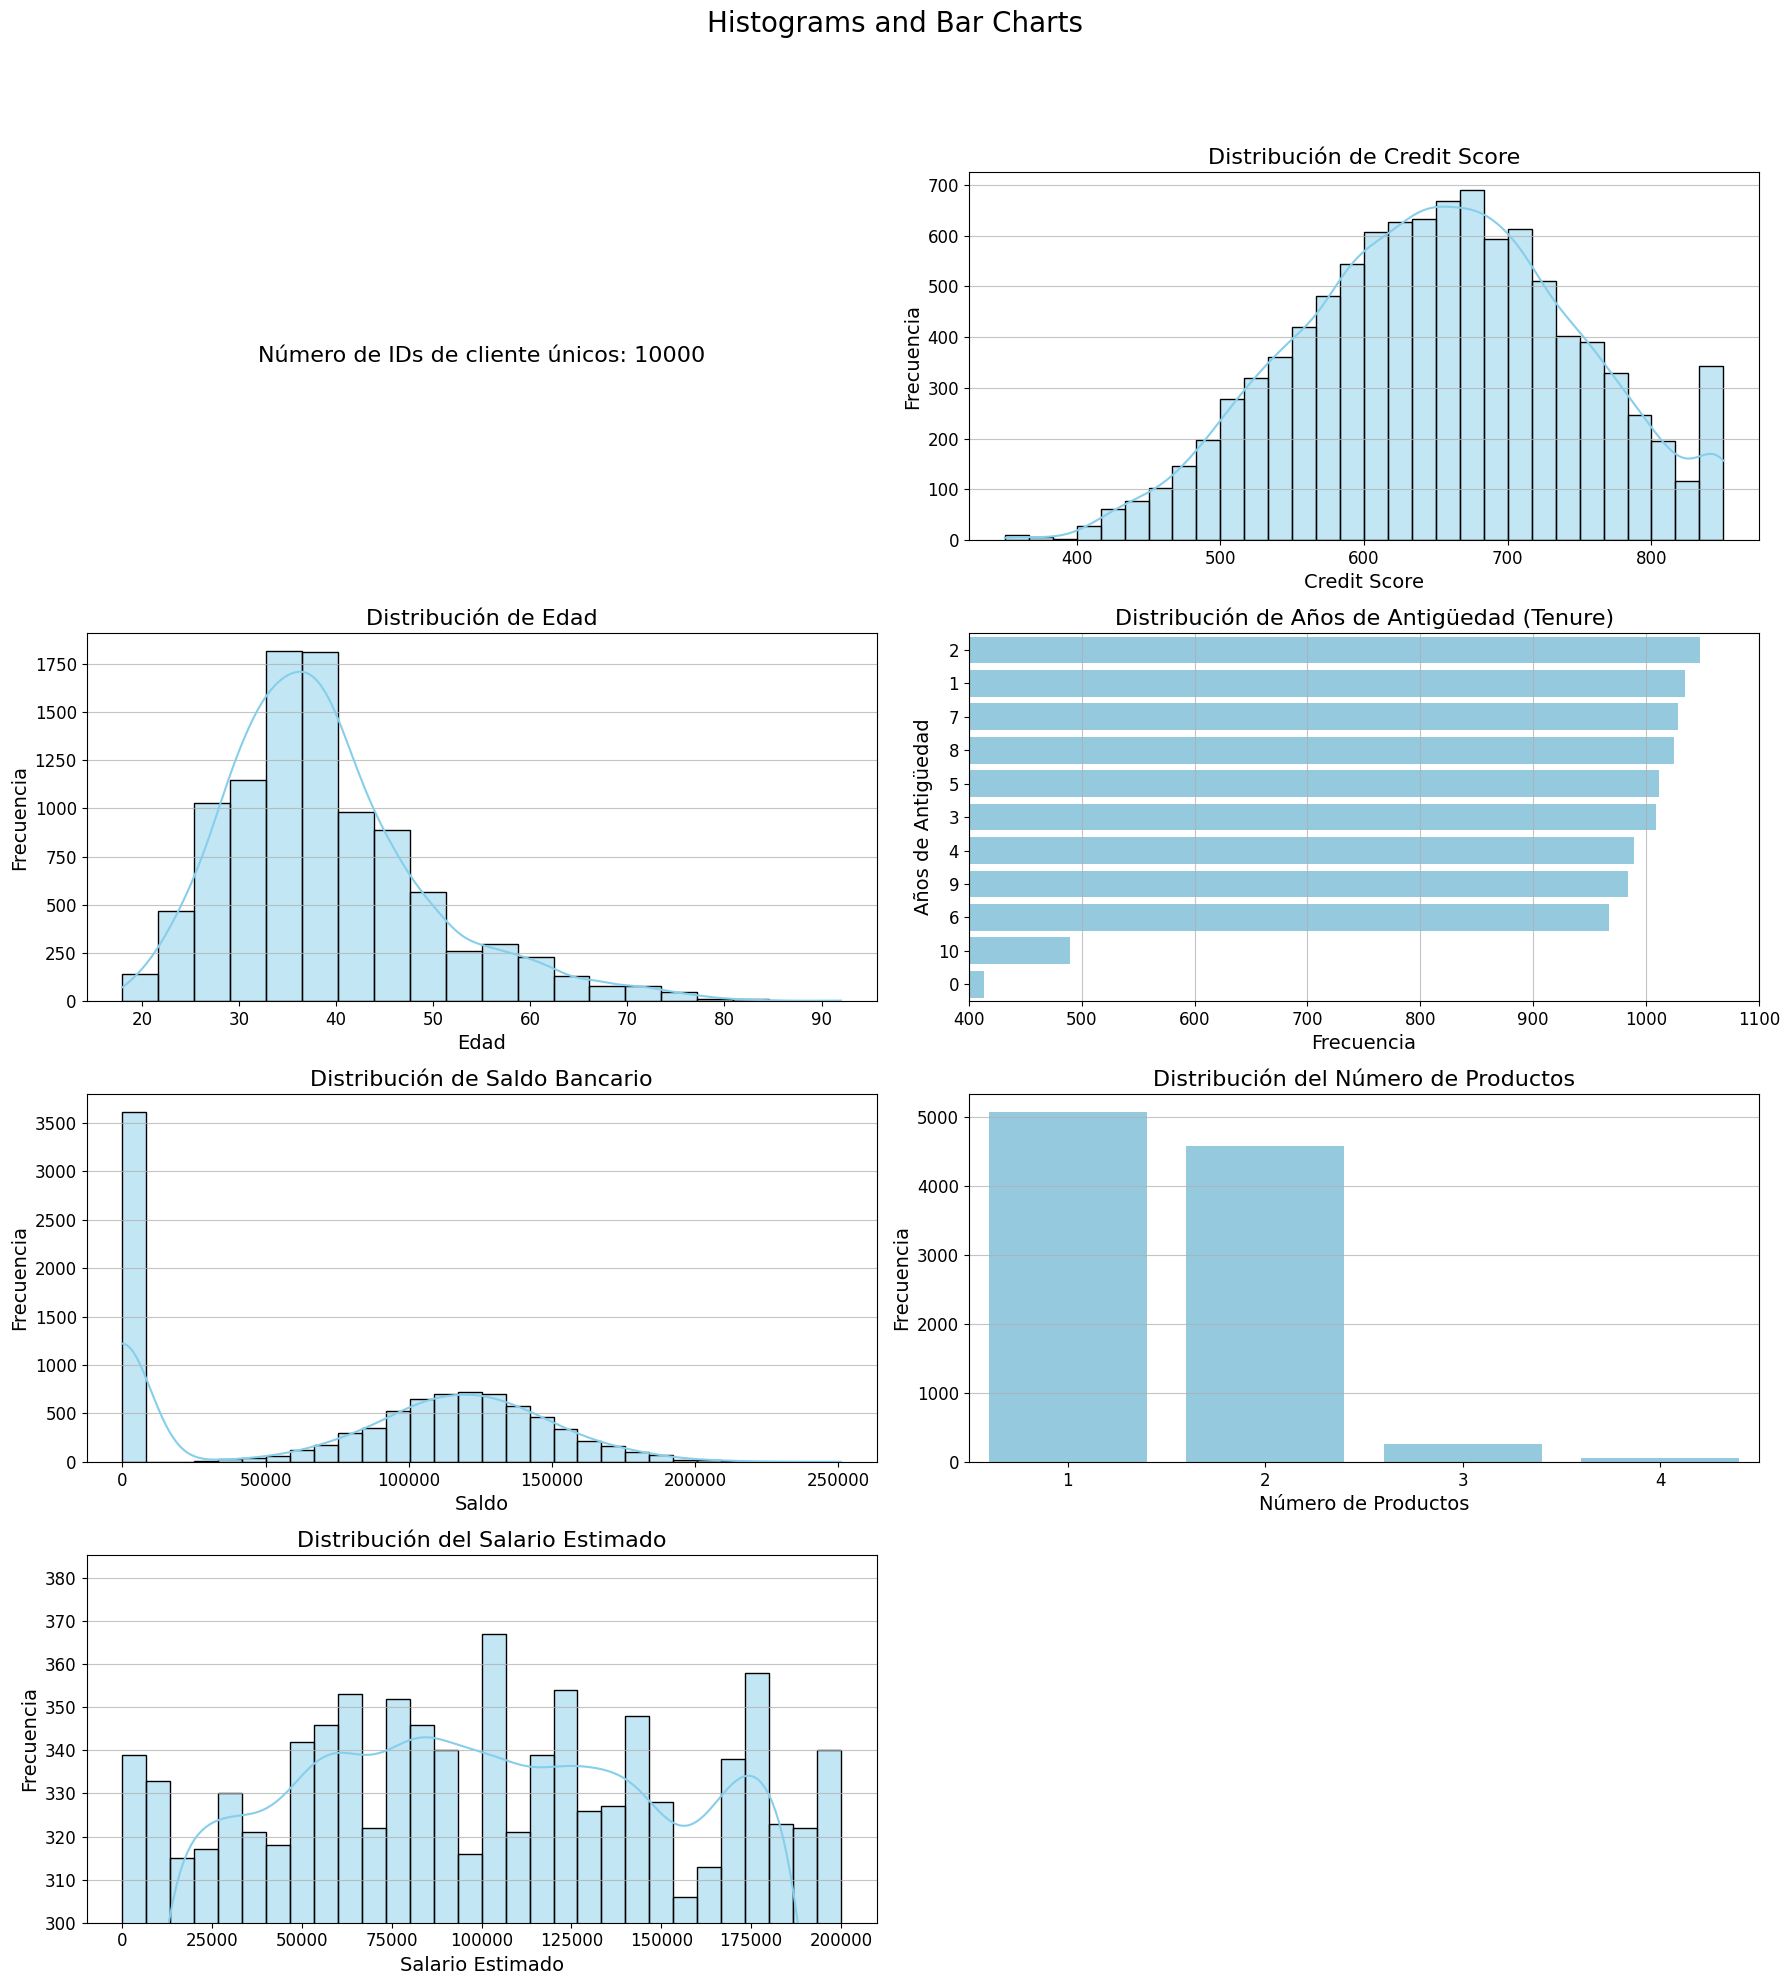

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(18, 20))
plt.suptitle('Histograms and Bar Charts', fontsize=20, y=1.02) # Increased suptitle fontsize

plt.subplot(4, 2, 1) # Placeholder for customer_id text
plt.axis('off') # Hide axes for text
plt.text(0.5, 0.5, f"Número de IDs de cliente únicos: {df['customer_id'].nunique()}",
         horizontalalignment='center', verticalalignment='center', fontsize=16) # Increased text fontsize

plt.subplot(4, 2, 2)
sns.histplot(df['credit_score'], bins=30, kde=True, color='skyblue')
plt.title('Distribución de Credit Score', fontsize=16) # Increased title fontsize
plt.xlabel('Credit Score', fontsize=14) # Increased xlabel fontsize
plt.ylabel('Frecuencia', fontsize=14) # Increased ylabel fontsize
plt.xticks(fontsize=12) # Increased xticks fontsize
plt.yticks(fontsize=12) # Increased yticks fontsize
plt.grid(axis='y', alpha=0.75)

plt.subplot(4, 2, 3)
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribución de Edad', fontsize=16) # Increased title fontsize
plt.xlabel('Edad', fontsize=14) # Increased xlabel fontsize
plt.ylabel('Frecuencia', fontsize=14) # Increased ylabel fontsize
plt.xticks(fontsize=12) # Increased xticks fontsize
plt.yticks(fontsize=12) # Increased yticks fontsize
plt.grid(axis='y', alpha=0.75)

plt.subplot(4, 2, 4)
sns.countplot(y=df['tenure'], color='skyblue', order=df['tenure'].value_counts().index)
plt.title('Distribución de Años de Antigüedad (Tenure)', fontsize=16) # Increased title fontsize
plt.xlabel('Frecuencia', fontsize=14) # Increased xlabel fontsize
plt.ylabel('Años de Antigüedad', fontsize=14) # Increased ylabel fontsize
plt.xticks(fontsize=12) # Increased xticks fontsize
plt.yticks(fontsize=12) # Increased yticks fontsize
plt.grid(axis='x', alpha=0.75)
plt.xlim(left=400) # Set x-axis to start from 400 as requested

plt.subplot(4, 2, 5)
sns.histplot(df['balance'], bins=30, kde=True, color='skyblue')
plt.title('Distribución de Saldo Bancario', fontsize=16) # Increased title fontsize
plt.xlabel('Saldo', fontsize=14) # Increased xlabel fontsize
plt.ylabel('Frecuencia', fontsize=14) # Increased ylabel fontsize
plt.xticks(fontsize=12) # Increased xticks fontsize
plt.yticks(fontsize=12) # Increased yticks fontsize
plt.grid(axis='y', alpha=0.75)

plt.subplot(4, 2, 6)
sns.countplot(x=df['products_number'], color='skyblue', order=df['products_number'].value_counts().index)
plt.title('Distribución del Número de Productos', fontsize=16) # Increased title fontsize
plt.xlabel('Número de Productos', fontsize=14) # Increased xlabel fontsize
plt.ylabel('Frecuencia', fontsize=14) # Increased ylabel fontsize
plt.xticks(fontsize=12) # Increased xticks fontsize
plt.yticks(fontsize=12) # Increased yticks fontsize
plt.grid(axis='y', alpha=0.75)

plt.subplot(4, 2, 7)
sns.histplot(df['estimated_salary'], bins=30, kde=True, color='skyblue')
plt.title('Distribución del Salario Estimado', fontsize=16) # Increased title fontsize
plt.xlabel('Salario Estimado', fontsize=14) # Increased xlabel fontsize
plt.ylabel('Frecuencia', fontsize=14) # Increased ylabel fontsize
plt.xticks(fontsize=12) # Increased xticks fontsize
plt.yticks(fontsize=12) # Increased yticks fontsize
plt.grid(axis='y', alpha=0.75)
plt.ylim(bottom=300) # Start y-axis from 300 as requested

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

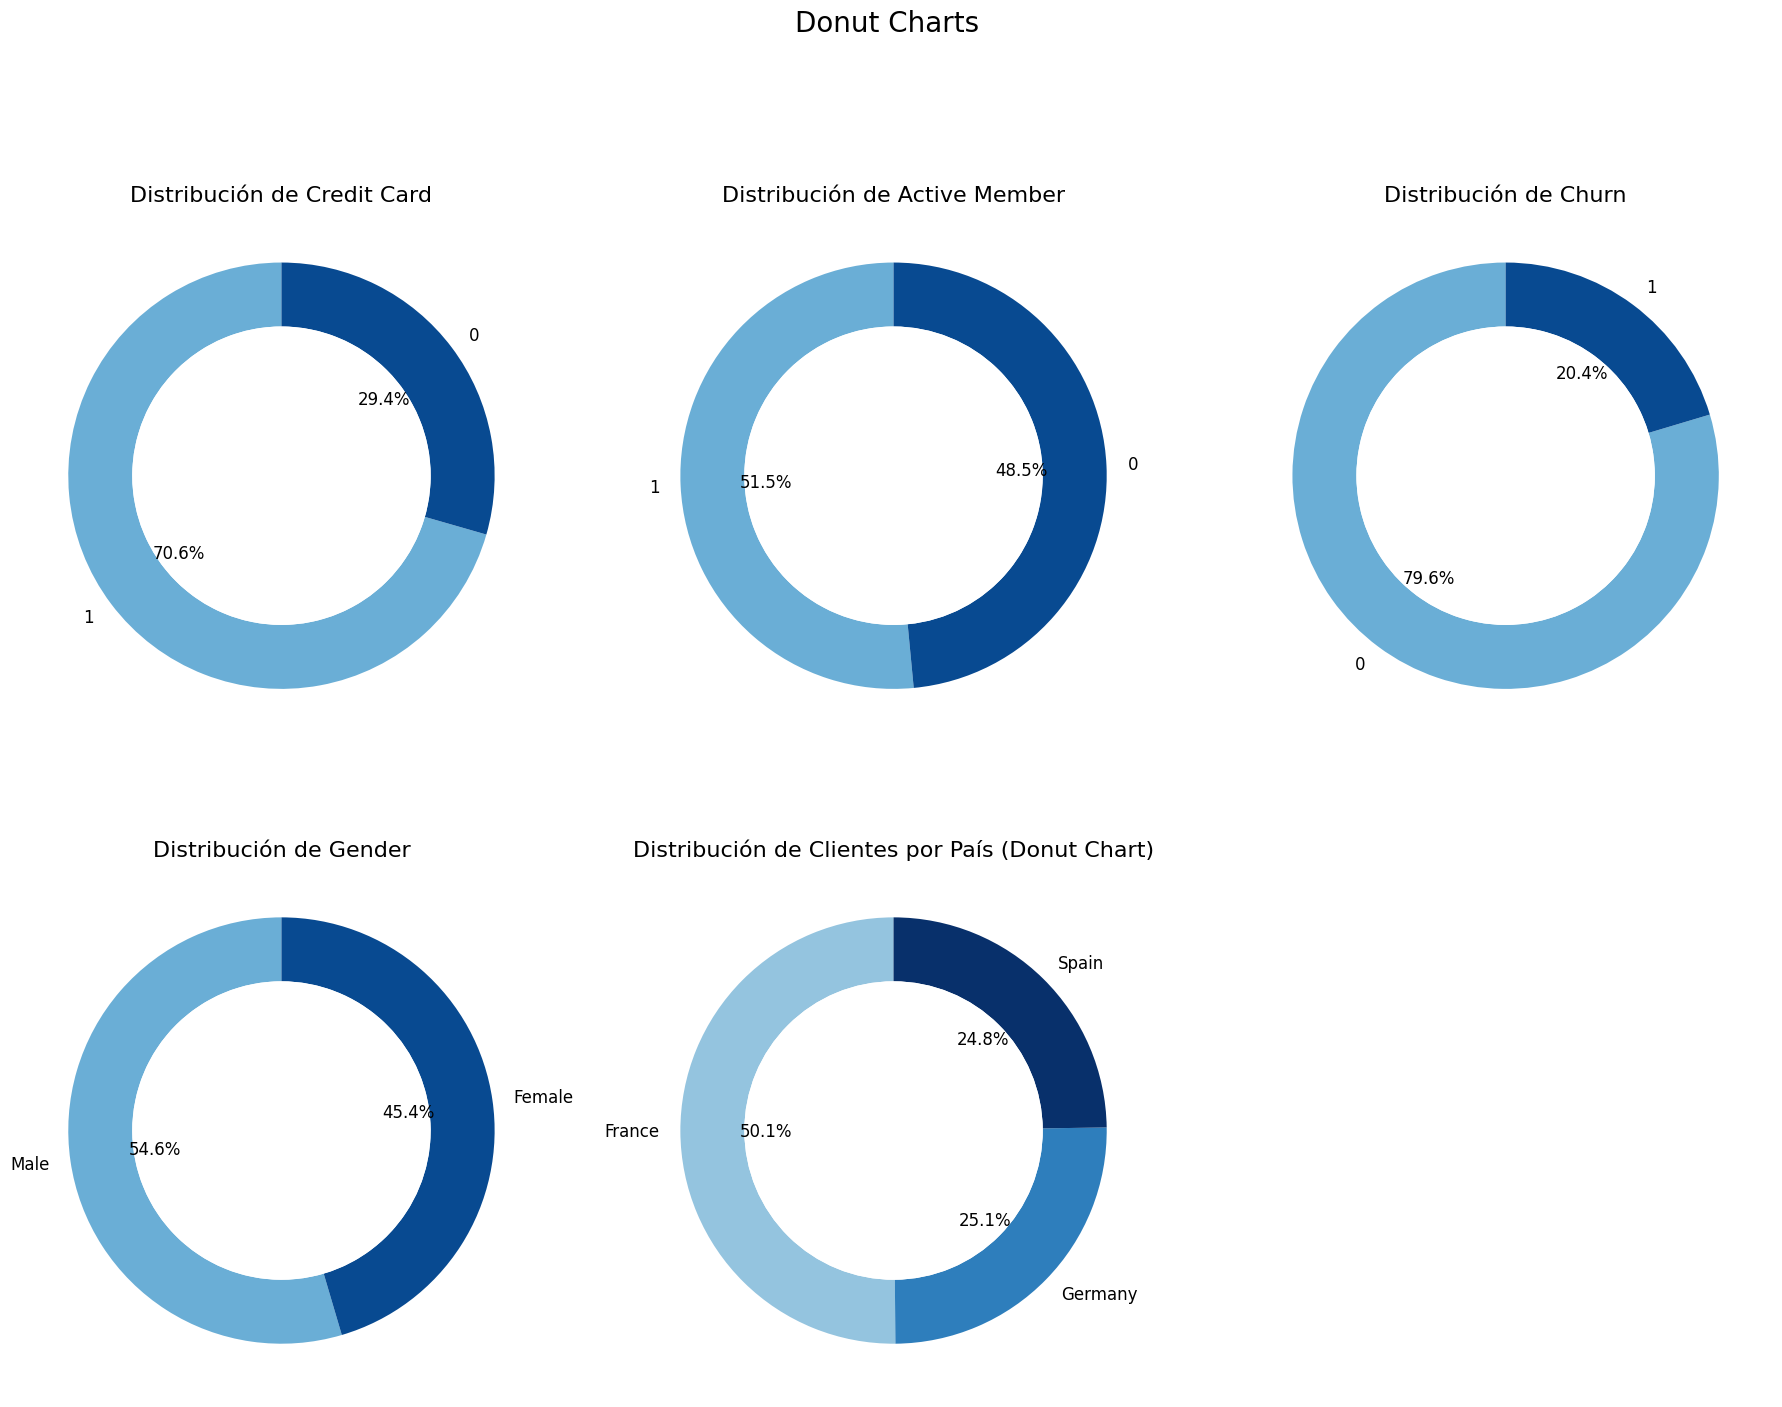

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Ensure numpy is imported for np.linspace

plt.figure(figsize=(18, 15))
plt.suptitle('Donut Charts', fontsize=20, y=1.02)

binary_cols = ['credit_card', 'active_member', 'churn', 'gender']

for i, col in enumerate(binary_cols):
    plt.subplot(2, 3, i + 1)
    counts = df[col].value_counts()
    colors_binary = plt.cm.Blues(np.linspace(0.5, 0.9, 2)) # Two shades of blue
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=colors_binary, wedgeprops={'width':0.3}, textprops={'fontsize': 12}) # Increased autopct fontsize
    centre_circle = plt.Circle((0,0),0.70,fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)
    plt.title(f'Distribución de {col.replace('_', ' ').title()}', fontsize=16) # Increased title fontsize
    plt.ylabel('')

plt.subplot(2, 3, 5)
country_counts = df['country'].value_counts()
colors_country = plt.cm.Blues(np.linspace(0.4, 1, len(country_counts)))
plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%', startangle=90, colors=colors_country, wedgeprops={'width':0.3}, textprops={'fontsize': 12}) # Increased autopct fontsize

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Distribución de Clientes por País (Donut Chart)', fontsize=16) # Increased title fontsize
plt.ylabel('') # Remove default 'country' label

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()



> Análisis bivariado



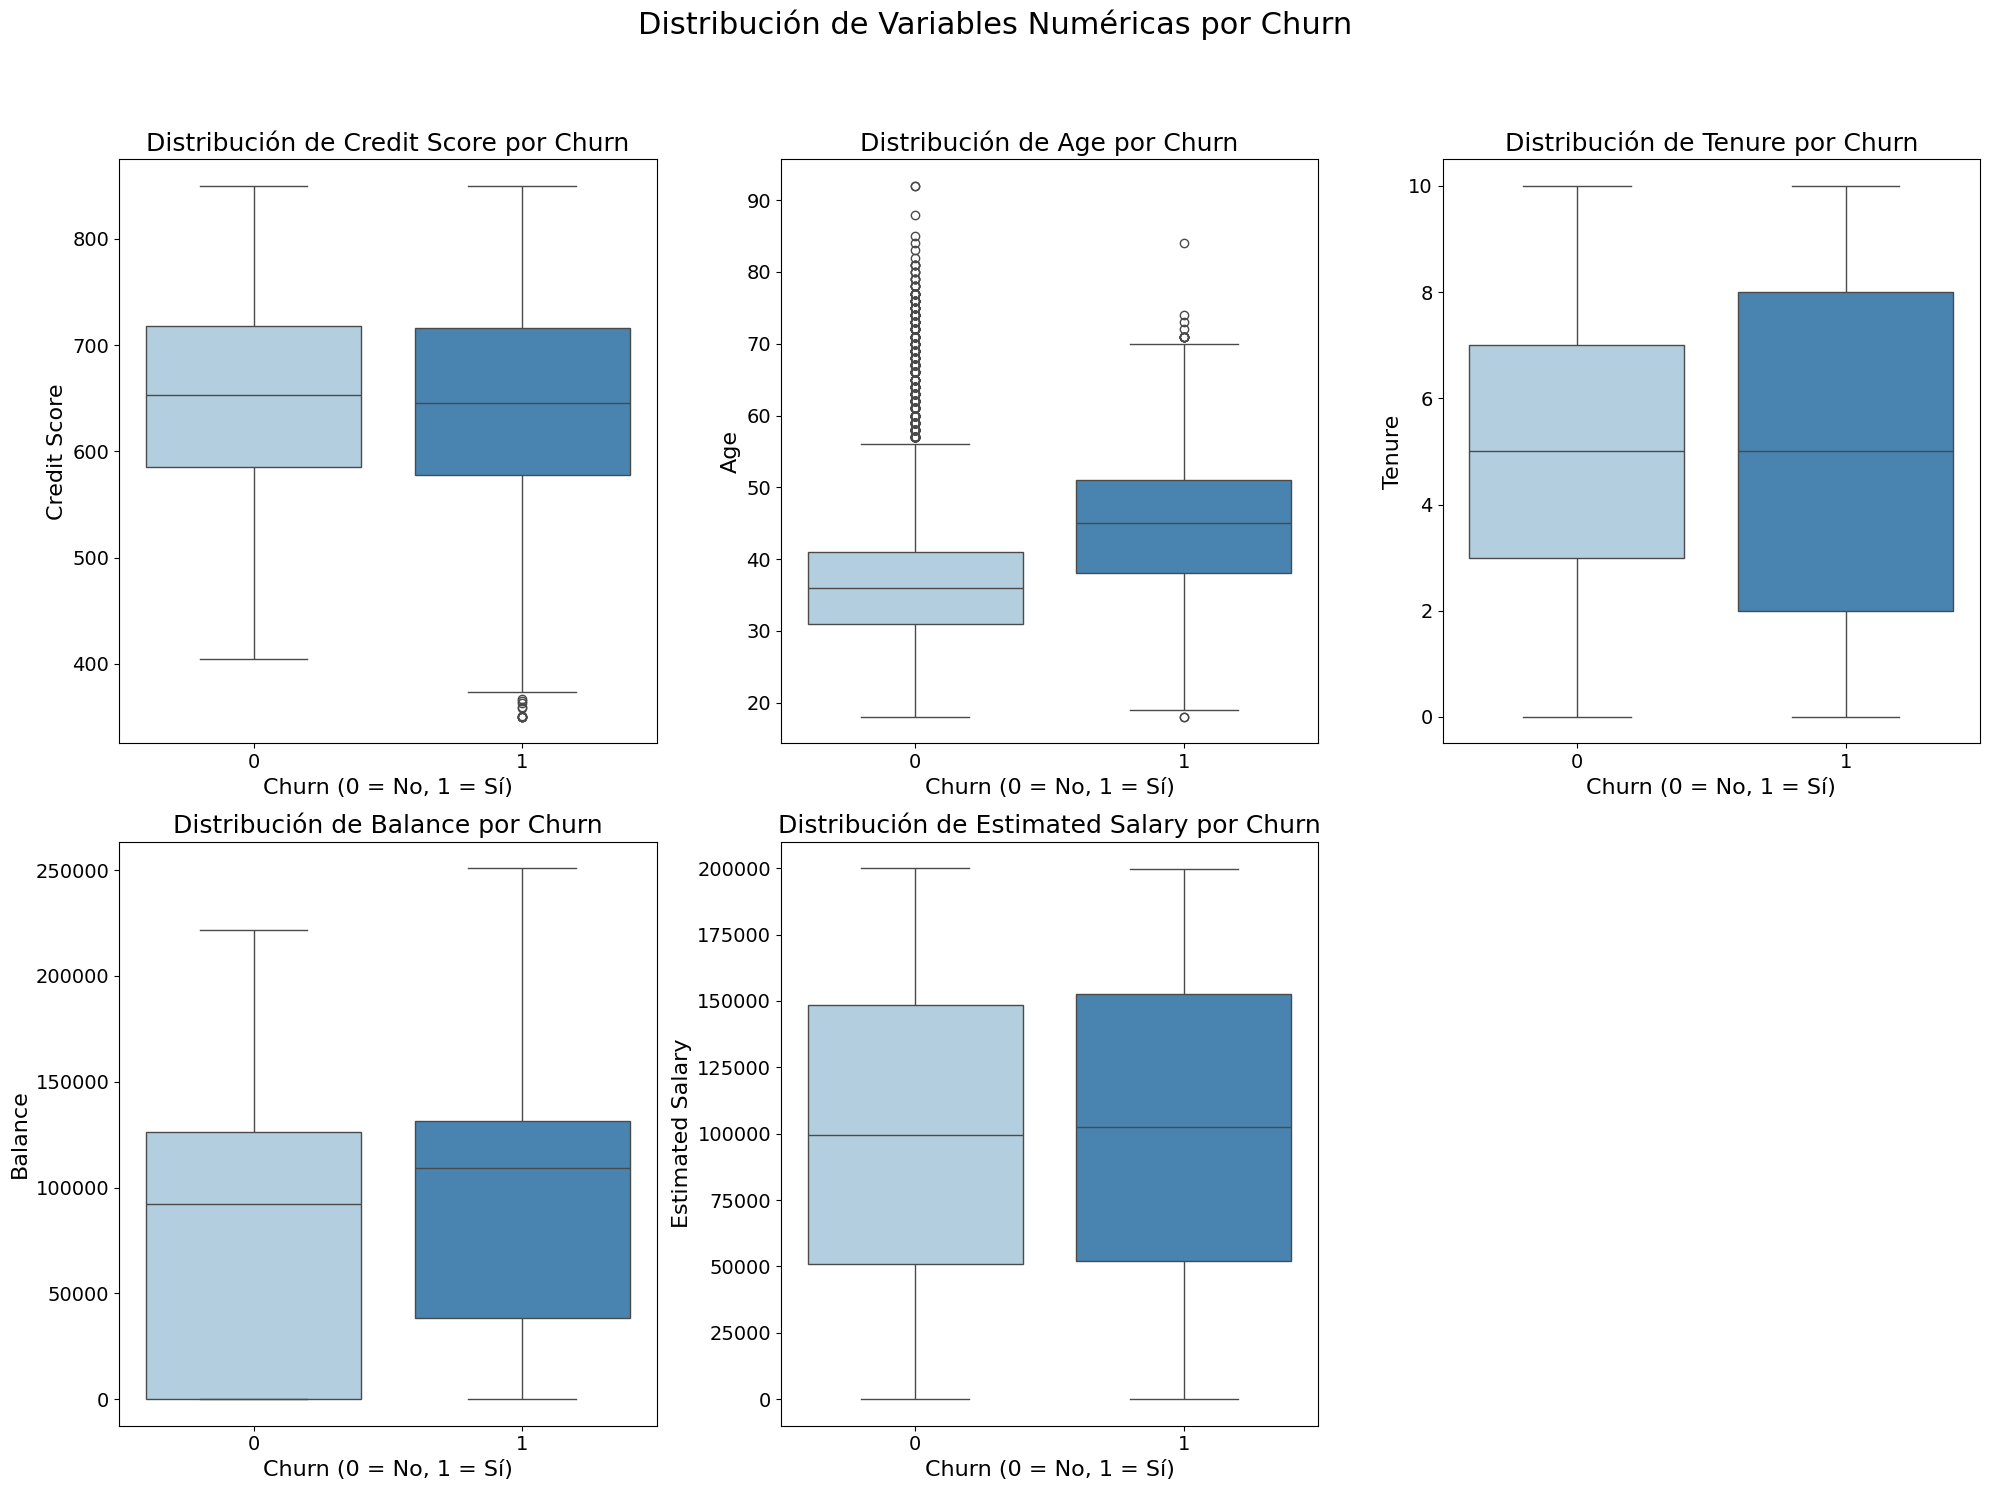

In [ ]:
numeric_vars = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']

plt.figure(figsize=(20, 15))
plt.suptitle('Distribución de Variables Numéricas por Churn', fontsize=22, y=1.02) # Increased suptitle fontsize

for i, var in enumerate(numeric_vars):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='churn', y=var, data=df, palette='Blues', hue='churn', legend=False)
    plt.title(f'Distribución de {var.replace('_', ' ').title()} por Churn', fontsize=18) # Increased title fontsize
    plt.xlabel('Churn (0 = No, 1 = Sí)', fontsize=16) # Increased xlabel fontsize
    plt.ylabel(var.replace('_', ' ').title(), fontsize=16) # Increased ylabel fontsize
    plt.xticks(fontsize=14) # Increased xticks fontsize
    plt.yticks(fontsize=14) # Increased yticks fontsize

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

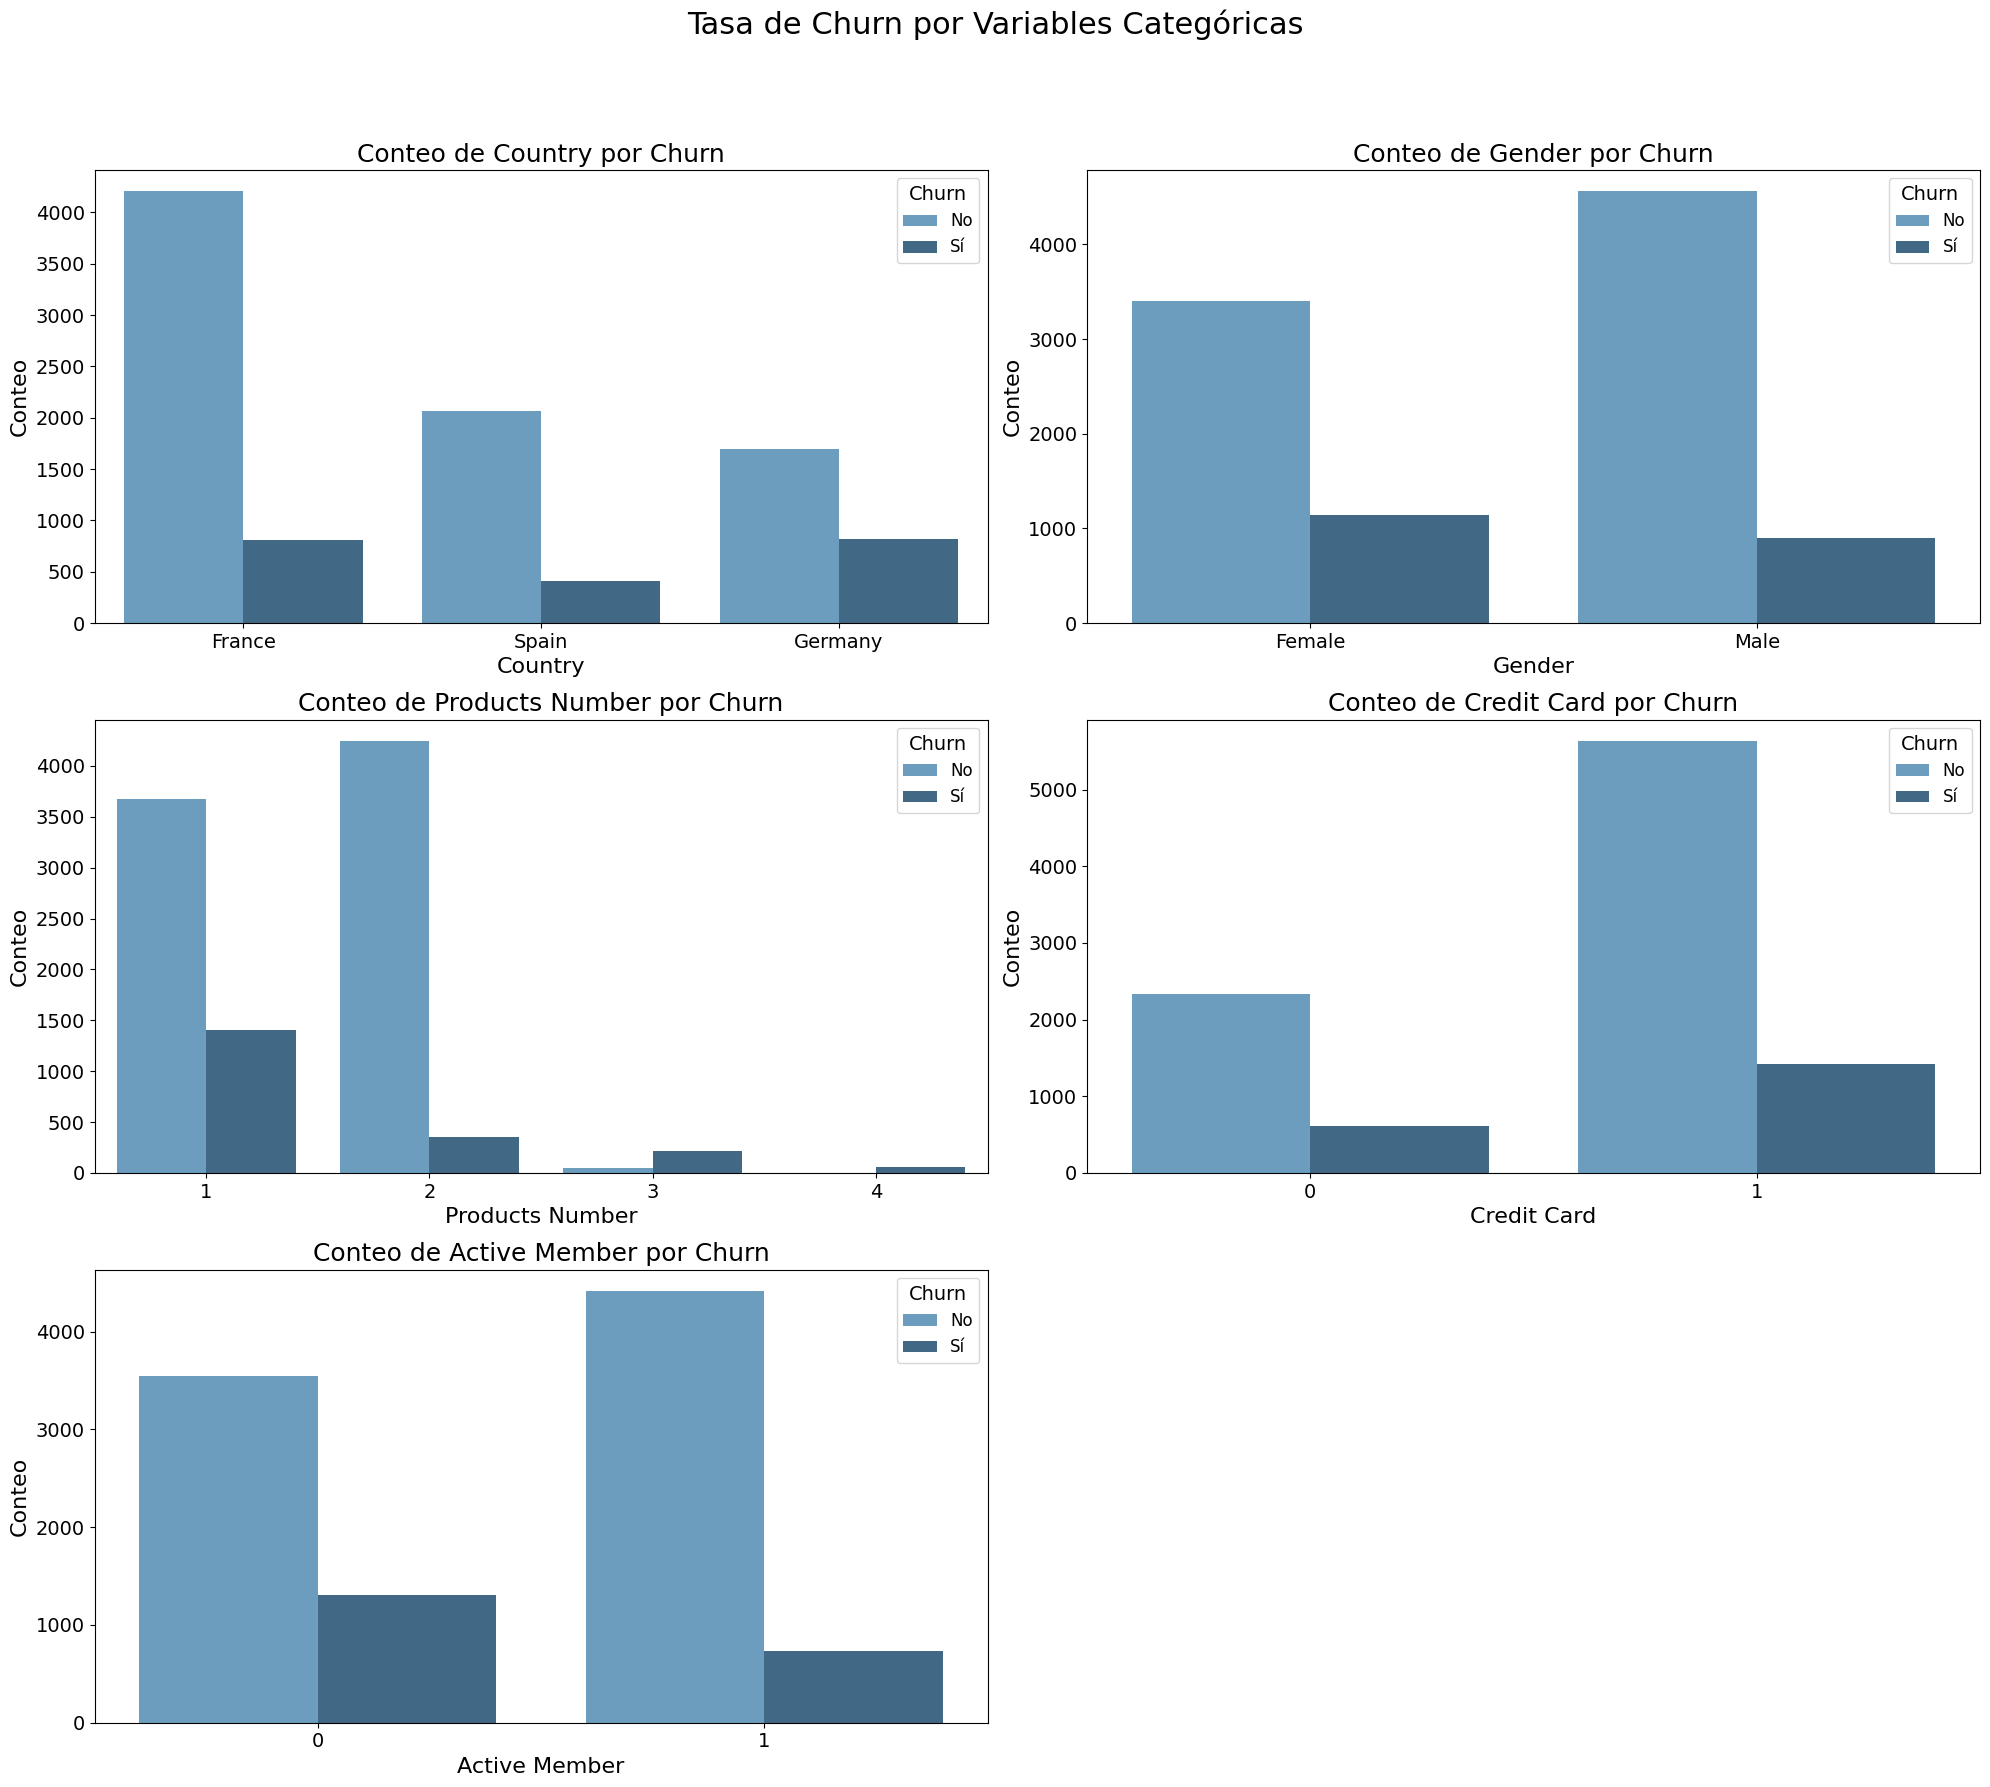

In [ ]:
categorical_vars = ['country', 'gender', 'products_number', 'credit_card', 'active_member']

plt.figure(figsize=(20, 18))
plt.suptitle('Tasa de Churn por Variables Categóricas', fontsize=22, y=1.02) # Increased suptitle fontsize

for i, var in enumerate(categorical_vars):
    plt.subplot(3, 2, i + 1)
    sns.countplot(x=var, hue='churn', data=df, palette='Blues_d')
    plt.title(f'Conteo de {var.replace('_', ' ').title()} por Churn', fontsize=18) # Increased title fontsize
    plt.xlabel(var.replace('_', ' ').title(), fontsize=16) # Increased xlabel fontsize
    plt.ylabel('Conteo', fontsize=16) # Increased ylabel fontsize
    plt.xticks(fontsize=14) # Increased xticks fontsize
    plt.yticks(fontsize=14) # Increased yticks fontsize
    plt.legend(title='Churn', labels=['No', 'Sí'], fontsize=12, title_fontsize=14) # Increased legend fontsize

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Análisis bivariado: factores determinantes en la fuga de clientes (Churn)

Nota metodológica: ¿Por qué evitamos un Mapa de Calor de Correlación tradicional?
Antes de analizar los gráficos, es crucial justificar la decisión metodológica de **no utilizar un mapa de calor de correlación tradicional (Pearson)** para evaluar el Churn:
1. **Incompatibilidad de la escala:** La correlación de Pearson está diseñada exclusivamente para medir relaciones lineales entre variables numéricas *continuas*. Al intentar cruzar variables categóricas (`Country`, `Gender`) o binarias (`Churn`, `Active Member`), el cálculo matemático colapsa o requiere transformaciones artificiales que restan interpretabilidad.
2.  **Subestimación del impacto (Efecto Atenuación):** Al cruzar variables continuas con binarias, Pearson asume una linealidad que no existe, arrojando coeficientes artificialmente cercanos a cero (ej. entre -0.1 y 0.1). Un mapa de calor nos habría llevado a la conclusión errónea de que variables como `Age` o `Balance` no guardan relación con la fuga.


Hallazgos en variables numéricas continuas

*   **Edad (`Age`) — El principal predictor demográfico:** Existe un claro desplazamiento hacia arriba en la mediana de edad del segmento que abandona la empresa (`Churn = 1`), situándose en torno a los **45 años**, en comparación con los clientes leales (`Churn = 0`), cuya mediana ronda los **36 años**. La fuga no es aleatoria; el riesgo aumenta significativamente en los segmentos de clientes de mediana edad y seniors.
*   **Saldo Bancario (`Balance`):** El gráfico confirma nuestra sospecha del análisis univariado. En el grupo que se queda (`Churn = 0`), la base de la caja llega a \$0 (una alta concentración de cuentas inactivas o sin fondos que no se molestan en cerrar la cuenta). Sin embargo, en el grupo que se fuga (`Churn = 1`), la mediana es visiblemente más alta y casi no posee registros en \$0. **Hallazgo crítico:** Son los clientes con saldos activos y fondos robustos los que están cerrando sus cuentas y retirando su capital.
*   **Puntaje de Crédito (`Credit Score`), Antigüedad (`Tenure`) y Salario Estimado (`Estimated Salary`):** Las distribuciones, medianas y rangos intercuartílicos son prácticamente idénticas entre ambos grupos. Esto demuestra que el poder adquisitivo, el comportamiento crediticio y los años de permanencia en la empresa **no son factores diferenciadores** a la hora de predecir la deserción.


Hallazgos en variables categóricas y binarias

Cruzando las frecuencias de participación con los gráficos de barras de **image_94981a.png** e **image_94983c.png**, extraemos conclusiones tácticas inmediatas:

*   **Riesgo Geográfico (Country):** Aunque Francia concentra la mayor cantidad de clientes en términos absolutos, el comportamiento de **Alemania** es alarmante. En Alemania, el volumen de clientes que se van (`Sí`) es prácticamente proporcional al que se queda (`No`), operando con una tasa de fuga interna cercana al **50%**, un valor que duplica con creces la tasa base global del 20.37%. España y Francia muestran un comportamiento maduro y controlado.
*   **Número de Productos (`Products Number`) — El umbral de fidelización:** Este gráfico revela una relación no lineal crítica. Los clientes con **1 producto** experimentan una fuga moderada-alta, pero al adquirir **2 productos**, la deserción cae a su mínimo histórico (alta fidelidad). Sin embargo, poseer **3 o 4 productos gatilla una fuga casi total (100%)**. Esto sugiere una posible fricción operativa: la sobreventa de productos o la complejidad en la gestión de cuentas correlaciona directamente con la pérdida del cliente.
*   **Compromiso del Cliente (`Active Member`):** Como era de esperarse, el grupo de miembros no activos (`Active Member = 0`) registra un volumen significativamente mayor de fugas en comparación con los activos. Mantener al cliente enganchado con la plataforma o servicios es un escudo directo contra el churn.
*   **Género (`Gender`) y Tarjeta de Crédito (`Credit Card`):** Las mujeres registran un volumen ligeramente superior de deserción en comparación con los hombres. Por otro lado, poseer o no tarjeta de crédito no altera significativamente las proporciones visuales de fuga, manteniendo un comportamiento alineado a la distribución original de la cartera.

In [ ]:
# Detección de valores atípicos (método IQR)
for col in ["credit_score", "age", "balance", "estimated_salary"]:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    n = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f"{col}: {n} outliers ({n/len(df)*100:.1f}%)")


credit_score: 15 outliers (0.1%)
age: 359 outliers (3.6%)
balance: 0 outliers (0.0%)
estimated_salary: 0 outliers (0.0%)


Identificación de valores atípicos mediante el método IQR (análisis univariado de outliers)

Para robustecer el análisis y entender si existen comportamientos extremos que puedan distorsionar los promedios o afectar futuros modelos predictivos, aplicamos el método del **Rango Intercuartílico ($IQR$)**. Definimos como *outliers* a todas aquellas observaciones que se encuentran fuera de los límites estadísticos convencionales:

$$Límite\ Inferior = Q_1 - 1.5 \times IQR$$
$$Límite\ Superior = Q_3 + 1.5 \times IQR$$

A continuación, se presentan los hallazgos para cada variable numérica:

*   **Puntaje de Crédito (`Credit Score`):** `15 outliers (0.15%)`. Representa una cantidad marginal de registros. Al revisar el gráfico de cajas previo, estos corresponden a clientes con puntajes inusualmente bajos (cercanos al mínimo de 350). Al ser tan pocos, no representan un riesgo de distorsión para el análisis global.
*   **Edad (`Age`):** `359 outliers (3.59%)`. Es la variable con mayor presencia de valores atípicos. Esto valida estadísticamente la asimetría positiva que detectamos al inicio: la empresa tiene un segmento "senior" (sobre los 62 años aproximadamente) que, aunque sale del comportamiento del cliente estándar, representa a un grupo real de la cartera que cursa con una dinámica de fuga distinta.
*   **Saldo Bancario (`Balance`):** `0 outliers (0.0%)`.
*   **Salario Estimado (`Estimated Salary`):** `0 outliers (0.0%)`.

> **Decisión Táctica de Negocio / Modelamiento:** Dado que la base de datos cuenta con 10,000 registros, la presencia de un 3.6% de outliers en la edad y un 0.1% en el puntaje de crédito no responde a errores de digitación ni "ruido", sino a segmentos reales de la población. Por lo tanto, se mantendrán estos registros en el dataset para no perder información valiosa sobre el comportamiento de los clientes de mayor edad, quienes precisamente evidenciaron una mayor tasa de deserción en las etapas visuales anteriores.

### Conclusiones del EDA

**Hallazgos principales:**
- **Datos limpios:** 10.000 filas, sin valores faltantes ni duplicados.
- **Clases desbalanceadas:** solo el **20 %** de los clientes abandona.
- **Variables más relacionadas con el churn:**
  - `products_number`: con 2 productos casi nadie se va, pero con 3 o 4 la fuga se dispara.
  - `country`: en Alemania abandonan el doble que en Francia o España.
  - `active_member`: los clientes inactivos se van más.
  - `age`: los que abandonan son mayores (≈45 vs ≈37 años).

**Decisiones justificadas:**

1. **¿Cómo tratamos los valores atípicos?**
   Solo `age` presenta algunos valores altos según el método IQR, pero corresponden a edades reales (no son errores de carga). Por eso **se conservan**, sin eliminar ni transformar.

2. **¿Cómo imputamos los datos faltantes?**
   **No se requiere imputación**, porque el dataset no tiene valores faltantes en ninguna columna.

3. **¿Hay variables que eliminar o transformar?**
   - **Eliminar:** `customer_id`, porque es solo un identificador único y no aporta información para predecir.
   - **Transformar:** las variables de texto `country` y `gender` deben codificarse (One-Hot Encoding) en la siguiente etapa para que el modelo pueda usarlas.




### 3. Preparación de los Datos

- Codifique las variables categóricas (p.ej., *One-Hot Encoding*).
- Escale las variables numéricas cuando sea necesario.
- Divida los datos en conjuntos de entrenamiento y prueba utilizando **estratificación**.
- Evalúe si existe **desbalance de clases** y cómo lo abordará (p.ej., SMOTE, pesos de clase).



In [ ]:
from sklearn.preprocessing import StandardScaler

df_bank = df.copy()

df_bank = df_bank.drop('customer_id', axis=1)

df_bank['gender'] = df_bank['gender'].map({'Female': 0, 'Male': 1})

df_bank = pd.get_dummies(df_bank, columns=['country'], drop_first=True, dtype=int)

numeric_cols_to_scale = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary', 'products_number']
scaler = StandardScaler()
df_bank[numeric_cols_to_scale] = scaler.fit_transform(df_bank[numeric_cols_to_scale])

display(df_bank.head())

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain
0,-0.326221,0,0.293517,-1.041760,-1.225848,-0.911583,1,1,0.021886,1,0,0
1,-0.440036,0,0.198164,-1.387538,0.117350,-0.911583,0,1,0.216534,0,0,1
2,-1.536794,0,0.293517,1.032908,1.333053,2.527057,1,0,0.240687,1,0,0
3,0.501521,0,0.007457,-1.387538,-1.225848,0.807737,0,0,-0.108918,0,0,0
4,2.063884,0,0.388871,-1.041760,0.785728,-0.911583,1,1,-0.365276,0,0,1


Consolidación del procesamiento de datos

Con base en los diagnósticos estadísticos previos, implementamos un flujo de transformación de datos definitivo sobre una copia de seguridad del dataset (`df_bank`). Este proceso prepara la matriz de características asegurando que el modelo de Machine Learning reciba la información optimizada, sin ruido y en la escala matemática correcta.

El código ejecuta de manera secuencial los siguientes 5 pasos fundamentales:

1.  **Resguardo de la base de datos (`df_bank = df.copy()`):** Creamos una copia explícita del DataFrame original para mantener las buenas prácticas de programación. Esto nos permite manipular los datos de forma segura sin alterar ni corromper la fuente de información primaria.
2.  **Eliminación de ruido / identificadores (`drop('customer_id')`):** Removemos la columna del identificador del cliente. Al ser un número correlativo único para cada observación, carece de poder predictivo o significado económico, y mantenerlo solo aportaría ruido e induciría al sobreajuste (*overfitting*) del modelo.
3.  **Codificación Binaria Eficiente (`gender.map`):** Transformamos la variable cualitativa de género directamente a un formato binario estructurado (`0` para Femenino, `1` para Masculino). Al tener solo dos categorías, esta aproximación evita la creación de columnas redundantes.
4.  **Codificación geográfica (`pd.get_dummies`):** Aplicamos *One-Hot Encoding* sobre la variable `country`. Configuramos el parámetro `drop_first=True` para omitir la primera categoría (Francia) por descarte matemático, eliminando el riesgo de correlación perfecta (trampa de la variable ficticia) y optimizando el uso de memoria.
5.  **Escalamiento por Estandarización (`StandardScaler`):** Seleccionamos el vector de variables numéricas y de conteo (`credit_score`, `age`, `tenure`, `balance`, `estimated_salary`, `products_number`) y les aplicamos una transformación Z-score. Esto centra sus medias en $0$ y sus desviaciones estándar en $1$, neutralizando la dominancia de las variables con montos nominales grandes (como salarios o saldos) sobre los algoritmos predictivos.

> **Nota de Integridad:** Como se fundamentó metodológicamente, la variable objetivo `churn` se mantuvo completamente excluida de este bloque de transformaciones para preservar intacta su naturaleza de etiqueta binaria de clasificación (`0` o `1`).

In [ ]:
from sklearn.model_selection import train_test_split

X = df_bank.drop('churn', axis=1)
y = df_bank['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape de X_train: {X_train.shape}")
print(f"Shape de X_test: {X_test.shape}")

print("\nDistribución de 'churn' en y_train:")
display(y_train.value_counts(normalize=True))
print("\nDistribución de 'churn' en y_test:")
display(y_test.value_counts(normalize=True))

Shape de X_train: (8000, 11)
Shape de X_test: (2000, 11)

Distribución de 'churn' en y_train:


,proportion
churn,
0,0.79625
1,0.20375



Distribución de 'churn' en y_test:


,proportion
churn,
0,0.7965
1,0.2035


Train-Test Split

Para evaluar el rendimiento real de nuestro modelo predictivo y prevenir problemas de sobreajuste (*overfitting*), separamos la base de datos transformante en dos conjuntos independientes: uno de **entrenamiento (80%)** y otro de **prueba (20%)**.

Importancia crítica de la estratificación

Dado que nuestro diagnóstico inicial reveló que la variable objetivo `churn` se encuentra desbalanceada (aproximadamente un **20.37% de deserción** frente a un 80% de retención), una división puramente aleatoria podría alterar estas proporciones en los subconjuntos, sesgando el aprendizaje del algoritmo o entregando métricas de validación engañosas.

Para mitigar esto, implementamos la **estratificación** mediante el parámetro `stratify=y`. Este enfoque garantiza:
1.  **Consistencia estadística:** El conjunto de entrenamiento (`y_train`) y el de prueba (`y_test`) repliquen de forma exacta la proporción original del 20.37% de fuga del negocio.
2.  **Validación rigurosa:** El modelo sea evaluado en un escenario real que refleja fielmente la distribución de la cartera de clientes de la empresa.

> **Configuración Técnica:** Establecemos un `random_state=42` para congelar la aleatoriedad de la partición. Esto asegura la **replicabilidad** del experimento.

Estrategia adoptada para el tratamiento del desbalance: pesos de clase (class weighting)

Tras evaluar que la base de datos presenta un desbalance moderado-crítico (donde la clase minoritaria de interés comercial, `churn = 1`, representa solo el ~20.37% del total), hemos decidido adoptar formalmente la estrategia de Ajuste de Pesos de Clase (`class_weight='balanced'`) para el desarrollo de todos los modelos predictivos posteriores.

Optamos por este enfoque por sobre las técnicas de remuestreo artificial (como SMOTE o submuestreo) debido a:

1.  **Preservación de la integridad de los datos reales:** Al no generar registros sintéticos artificiales, garantizamos que el modelo aprenda exclusivamente de los comportamientos y perfiles financieros reales de la cartera de clientes del banco, evitando introducir ruido estadístico o varianza artificial en el conjunto de entrenamiento.
2.  **Eficiencia y simplicidad del pipeline:** Esta técnica no altera la estructura ni las dimensiones de las matrices `X_train` e `y_train` obtenidas en la partición estratificada. El balanceo ocurre internamente durante la optimización matemática del algoritmo, manteniendo el código limpio, reproducible y eficiente en términos de memoria.
3.  **Penalización simétrica del error de negocio:** En términos prácticos, al activar el parámetro `balanced`, el algoritmo reajusta automáticamente su función de pérdida. Esto significa que **castigará con una severidad aproximadamente 4 veces mayor** un Falso Negativo (un cliente en riesgo de fuga que el modelo no logra detectar) en comparación con un Falso Positivo. Esto fuerza a los modelos a priorizar la sensibilidad (*Recall*), maximizando la captura de clientes propensos a abandonar el banco.

> **Implementación en el Código:** En las celdas consecutivas de modelamiento, esta estrategia se verá reflejada directamente al instanciar cada algoritmo de clasificación (por ejemplo, `LogisticRegression(class_weight='balanced')` o `RandomForestClassifier(class_weight='balanced')`), aplicando un criterio de evaluación unificado para todas las arquitecturas a comparar.



### 4. Fase de Modelado

Deberá construir **cuatro modelos de clasificación**:

#### 4.1 Regresión Logística
- Utilícela como **modelo de referencia (*baseline*)**.
- Explique los coeficientes e interprételos en términos de probabilidad de *churn*.

#### 4.2 Árbol de Decisión
- Realice ajuste de hiperparámetros (p.ej., `max_depth`, `min_samples_split`, `min_samples_leaf`).

#### 4.3 Random Forest
- Utilice búsqueda aleatoria o exhaustiva de hiperparámetros (p.ej., número de árboles, profundidad, tamaño de hoja).

#### 4.4 Gradient Boosting
- Ajuste la tasa de aprendizaje, la profundidad y el número de estimadores.
- Argumente por qué el *boosting* podría superar a los demás modelos.





> Regresión logística



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

log_reg = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced') # 'liblinear' es bueno para datasets pequeños y para L1/L2 regularization
log_reg.fit(X_train, y_train)

y_pred_log_reg = log_reg.predict(X_test)
y_prob_log_reg = log_reg.predict_proba(X_test)[:, 1]

print("--- Evaluación del Modelo de Regresión Logística ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_log_reg))

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_log_reg),
                     index=['Actual No Churn', 'Actual Churn'],
                     columns=['Predicted No Churn', 'Predicted Churn']))

# Interpretar coeficientes
print("\nCoeficientes de la Regresión Logística:")
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': log_reg.coef_[0]})
coefficients['Odds Ratio'] = np.exp(coefficients['Coefficient'])
# Mejora visual de la tabla (opcional)
coefficients = coefficients.sort_values(by='Odds Ratio', ascending=False).reset_index(drop=True)
display(coefficients.style.background_gradient(cmap='RdYlGn_r', subset=['Odds Ratio']))

--- Evaluación del Modelo de Regresión Logística ---

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000


ROC-AUC Score: 0.7771747093780992

Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,1142,451
Actual Churn,122,285



Coeficientes de la Regresión Logística:


,Feature,Coefficient,Odds Ratio
0,country_Germany,0.823262,2.277919
1,age,0.798552,2.222322
2,balance,0.175996,1.192433
3,country_Spain,0.054997,1.056538
4,estimated_salary,0.050680,1.051987
5,tenure,-0.018753,0.981422
6,products_number,-0.057817,0.943823
7,credit_card,-0.068677,0.933628
8,credit_score,-0.087125,0.916563
9,gender,-0.545328,0.579652


Análisis de impacto de negocio

A partir de los Odds ratios obtenidos en nuestro modelo de regresión logística, podemos segmentar las palancas del negocio en tres categorías críticas para la toma de decisiones:

1.  **Alertas Rojas (Factores de Mayor Riesgo):** El mercado de **Alemania** (`country_Germany` con OR de 2.28) y la **Edad** (`age` con OR de 2.22) son los predictores más agresivos de la deserción. Un cliente alemán o de edad avanzada duplica holgadamente el riesgo de fuga. Asimismo, el **Saldo** (`balance` con OR de 1.19) demuestra que el banco está perdiendo a sus clientes de mayor valor patrimonial, lo que exige una estrategia urgente de retención premium.

2.  **Anclas de Retención (Factores Protectores):** La variable **Miembro Activo** (`active_member` con OR de 0.41) es la herramienta de fidelización más potente del dataset, reduciendo la probabilidad de abandono en un 59%. Esto demuestra que las estrategias de engagement e interacción diaria con el cliente son altamente efectivas. Por otro lado, el **Género Masculino** (`gender` con OR de 0.58) presenta un 42% menos de riesgo de fuga en comparación con el segmento femenino.

3.  **Variables Marginales:** Atributos como el salario estimado, el puntaje crediticio o la antigüedad (`tenure`) muestran Odds Ratios muy cercanos a 1.00, lo que indica que su peso relativo al momento de decidir abandonar la institución es secundario frente a los factores geográficos y de actividad.

Interpretación econométrica de los Odds Ratios

La estructura formal para interpretar estos resultados se define bajo la siguiente regla de cambio porcentual:

$$\Delta\% = (\text{Odds Ratio} - 1) \times 100$$

Esto nos permite traducir los impactos matemáticos directamente al lenguaje de gestión y estrategia de negocios:

####1.  Variables de riesgo (OR > 1: multiplican e incrementan el riesgo)
*   **Saldo de la cuenta (`balance` | OR = 1.192):** Por cada unidad que aumenta el saldo de la cuenta de un cliente, los odds de que abandone la institución **se multiplican por 1.192**, lo que equivale a un **incremento neto del 19.2%** en sus posibilidades de fuga.

*   **Mercado de Alemania (`country_Germany` | OR = 2.278):** Manteniendo el resto de las variables constantes, el solo hecho de que un cliente pertenezca al mercado alemán (en comparación con la base de Francia) **multiplica sus odds de fuga por 2.278**, representando un **aumento drástico del 127.8%** en el riesgo de abandono.

#### 2. Variables protectoras (OR < 1: multiplican y disminuyen el riesgo)
*   **Miembro Activo (`active_member` | OR = 0.414):** Cuando un cliente pasa a ser un miembro activo de la institución, sus odds de deserción **se multiplican por 0.414**. Esto se traduce en una **reducción neta del 58.6%** en sus posibilidades de fuga.

*   **Género Masculino (`gender` | OR = 0.580):** En nuestra muestra, el perfil masculino **multiplica los odds de churn por 0.580**, lo que equivale a tener un **42.0% menos de posibilidades de fuga** en comparación con el segmento femenino.



> Árbol de decisión



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Inicializar y entrenar el modelo de Árbol de Decisión
# Usaremos parámetros por defecto inicialmente, luego se puede realizar el ajuste de hiperparámetros.
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Evaluar el modelo
print("--- Evaluación del Modelo de Árbol de Decisión ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_dt))

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_dt),
                     index=['Actual No Churn', 'Actual Churn'],
                     columns=['Predicted No Churn', 'Predicted Churn']))

--- Evaluación del Modelo de Árbol de Decisión ---

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1593
           1       0.45      0.46      0.45       407

    accuracy                           0.78      2000
   macro avg       0.65      0.66      0.66      2000
weighted avg       0.78      0.78      0.78      2000


ROC-AUC Score: 0.6569381399889874

Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,1365,228
Actual Churn,221,186


Modelo de árbol de decisión (enfoque inicial no optimizado)

En esta primera etapa, entrenamos el algoritmo manteniendo sus hiperparámetros estructurales por defecto (permitiendo que el árbol crezca libremente) pero aplicando nuestra estrategia de **pesos de clase balanceados para mantener la simetría metodológica con el modelo baseline.

###El peligro del árbol por defecto: overfitting absoluto

Es fundamental destacar que un árbol de decisión entrenado sin límites de profundidad (`max_depth=None`) tiende a memorizar el conjunto de entrenamiento de forma perfecta, ramificándose hasta que cada hoja contenga un solo registro de datos. Esto genera un fenómeno severo de **sobreajuste (*overfitting*)**, donde el modelo tendrá métricas perfectas en entrenamiento pero un rendimiento deficiente y con alta varianza al enfrentarse a datos nuevos en el conjunto de prueba (`X_test`).

> **Propósito del Experimento:** Dejar el árbol correr de forma libre en esta celda nos servirá como un "punto de control negativo". Nos permitirá contrastar matemáticamente qué tan destructivo es el sobreajuste y justificará la necesidad técnica de realizar un ajuste de hiperparámetros (*Hyperparameter Tuning*) en el siguiente paso para "podar" el árbol y mejorar su capacidad de generalización comercial.

#### Ajuste de hiperparámetros para el árbol de decisión

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Definir los hiperparámetros a ajustar
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None], # Profundidad máxima del árbol
    'min_samples_split': [2, 5, 10, 20], # Número mínimo de muestras requeridas para dividir un nodo interno
    'min_samples_leaf': [1, 2, 4, 8], # Número mínimo de muestras requeridas para ser un nodo hoja
    'criterion': ['gini', 'entropy'] # Función para medir la calidad de una división
}

dt_base = DecisionTreeClassifier(random_state=42, class_weight='balanced')

grid_search_dt = GridSearchCV(estimator=dt_base,
                              param_grid=param_grid_dt,
                              scoring='roc_auc', # Usamos ROC-AUC como métrica principal
                              cv=5, # 5-fold cross-validation
                              n_jobs=-1, # Usar todos los procesadores disponibles
                              verbose=1)

grid_search_dt.fit(X_train, y_train)

print(f"Mejores parámetros para el Árbol de Decisión: {grid_search_dt.best_params_}")
print(f"Mejor ROC-AUC en el conjunto de entrenamiento: {grid_search_dt.best_score_:.4f}")

best_dt_model = grid_search_dt.best_estimator_

y_pred_best_dt = best_dt_model.predict(X_test)
y_prob_best_dt = best_dt_model.predict_proba(X_test)[:, 1]

print("\n--- Evaluación del Mejor Modelo de Árbol de Decisión (con Hiperparámetros Ajustados) ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_dt))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_best_dt))

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_best_dt),
                     index=['Actual No Churn', 'Actual Churn'],
                     columns=['Predicted No Churn', 'Predicted Churn']))

Fitting 5 folds for each of 160 candidates, totalling 800 fits
Mejores parámetros para el Árbol de Decisión: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 2}
Mejor ROC-AUC en el conjunto de entrenamiento: 0.8369

--- Evaluación del Mejor Modelo de Árbol de Decisión (con Hiperparámetros Ajustados) ---

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.74      0.82      1593
           1       0.44      0.80      0.56       407

    accuracy                           0.75      2000
   macro avg       0.68      0.77      0.69      2000
weighted avg       0.83      0.75      0.77      2000


ROC-AUC Score: 0.8416328501074264

Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,1173,420
Actual Churn,83,324


Análisis comparativo: árbol base vs. árbol optimizado

El proceso de ajuste de hiperparámetros generó un impacto crítico en la estructura del modelo, transformando un árbol con bajo poder predictivo en una herramienta comercial de alto valor estratégico para el banco.

#### Cuadro Comparativo de Métricas Clave

| Métrica | Árbol Base (Sin Regularizar) | Árbol Optimizado (GridSearchCV) | Impacto / Negocio |
| :--- | :---: | :---: | :--- |
| **ROC-AUC Score** | 0.6569 | **0.8416** | **+18.47%** Incremento masivo en la capacidad general de discriminación del modelo. |
| **Recall Clase 1 (Fuga)** | 45.70% | **79.60%** | **+33.90%** Pasamos de detectar menos de la mitad a capturar casi 8 de cada 10 clientes en riesgo. |
| **Falsos Negativos (Clientes no detectados)** | 221 | **83** | **Reducción del 62.4%** El banco disminuye drásticamente sus "puntos ciegos" de fuga. |
| **Precision Clase 1** | 45.0% | 43.5% | Se mantiene prácticamente estable (~1.5% de variación), un costo operativo mínimo para el tremendo beneficio en captura. |

---

Diagnóstico Técnico y de Negocio

#### 1. Evidencia del quiebre del overfitting
El **árbol base** arrojó un ROC-AUC deficiente (0.6569). Al crecer sin restricciones, el algoritmo memorizó ruidos del set de entrenamiento, generando reglas hiper-específicas que fallaron al enfrentarse a los datos nuevos de prueba (`X_test`). Al aplicar `GridSearchCV` y restringir el árbol con parámetros de poda (`max_depth`, `min_samples_split`, `min_samples_leaf`), forzamos al modelo a buscar patrones generales y estables. El resultado es un incremento de más de 18 puntos porcentuales en el ROC-AUC de prueba, demostrando una **robusta capacidad de generalización**.

#### 2. Maximización del impacto comercial (Recall)
Desde la perspectiva de la gestión bancaria, un **Falso Negativo** (no detectar a un cliente que se va a fugar) es el error más costoso, ya que recuperar a un cliente perdido es más caro que retenerlo de forma proactiva.
*   El modelo base dejaba partir a **221 clientes** sin levantar ninguna alerta.
*   El modelo optimizado redujo esa fuga ciega a solo **83 clientes**, elevando el **Recall del Churn al 79.6%**.

#### 3. Compensación de costos operativos (Trade-off de precisión)
Para lograr capturar a casi el 80% de los clientes en riesgo, el modelo optimizado incrementó los Falsos Positivos (clientes estables que el modelo etiqueta como "en riesgo de fuga") de 228 a 420. Esto explica la leve baja en la precisión de la clase 1 (de 45% a 43.5%) y la baja en el Accuracy general (78% a 75%).

**Decisión Estratégica:** este *trade-off* está plenamente justificado. Es comercialmente preferible que el equipo de fidelización del banco realice campañas preventivas (como llamados de ejecutivos o envío de ofertas de retención) a 420 clientes estables, antes que permitir que 221 clientes reales de alto valor abandonen la institución en absoluto silencio.



> Random forest



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Inicializar y entrenar el modelo de Random Forest
# Usaremos parámetros por defecto inicialmente, luego se realizará el ajuste de hiperparámetros
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluar el modelo
print("--- Evaluación del Modelo de Random Forest ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_rf),
                     index=['Actual No Churn', 'Actual Churn'],
                     columns=['Predicted No Churn', 'Predicted Churn']))

--- Evaluación del Modelo de Random Forest ---

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.79      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.74      2000
weighted avg       0.85      0.86      0.85      2000


ROC-AUC Score: 0.8536895909777266

Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,1545,48
Actual Churn,229,178


Modelo de random forest (enfoque inicial no optimizado)

Como tercer modelo predictivo de nuestro proyecto, implementamos un **Random Forest**. A diferencia del árbol de decisión simple, Random Forest es un algoritmo de *Ensemble Learning* (aprendizaje de conjunto) que construye múltiples árboles de decisión independientes durante el entrenamiento y combina sus predicciones mediante votación mayoritaria.


> **Por qué usar Random Forest de Baseline:** Al promediar los resultados de muchos árboles entrenados con distintas submuestras de datos (técnica conocida como *Bagging*), este modelo reduce de forma natural la varianza y el sobreajuste que afectaban a nuestro árbol simple. Esto nos entregará una base mucho más robusta antes de iniciar la búsqueda aleatoria o exhaustiva de hiperparámetros.

Ajuste de hiperparámetros para random forest

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Definir los hiperparámetros a ajustar para Random Forest
param_grid_rf = {
    'n_estimators': [100, 200], # Número de árboles en el bosque
    'max_depth': [5, 10, None], # Profundidad máxima de cada árbol
    'min_samples_split': [2, 10], # Número mínimo de muestras requeridas para dividir un nodo interno
    'min_samples_leaf': [1, 4], # Número mínimo de muestras requeridas para ser un nodo hoja
    # 'criterion': ['gini'] # Función para medir la calidad de una división
}

# Inicializar el modelo base
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

# Inicializar GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf_base,
                              param_grid=param_grid_rf,
                              scoring='roc_auc', # Usamos ROC-AUC como métrica principal
                              cv=3, # 3-fold cross-validation para agilizar el proceso
                              n_jobs=-1, # Usar todos los procesadores disponibles
                              verbose=1)

# Ejecutar la búsqueda en malla
grid_search_rf.fit(X_train, y_train)

# Mostrar los mejores parámetros y el mejor score
print(f"Mejores parámetros para Random Forest: {grid_search_rf.best_params_}")
print(f"Mejor ROC-AUC en el conjunto de entrenamiento: {grid_search_rf.best_score_:.4f}")

# Obtener el mejor modelo
best_rf_model = grid_search_rf.best_estimator_

# Evaluar el mejor modelo en el conjunto de prueba
y_pred_best_rf = best_rf_model.predict(X_test)
y_prob_best_rf = best_rf_model.predict_proba(X_test)[:, 1]

print("\n--- Evaluación del Mejor Modelo de Random Forest (con Hiperparámetros Ajustados) ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_rf))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_best_rf))

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_best_rf),
                     index=['Actual No Churn', 'Actual Churn'],
                     columns=['Predicted No Churn', 'Predicted Churn']))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Mejores parámetros para Random Forest: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Mejor ROC-AUC en el conjunto de entrenamiento: 0.8629

--- Evaluación del Mejor Modelo de Random Forest (con Hiperparámetros Ajustados) ---

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1593
           1       0.58      0.68      0.62       407

    accuracy                           0.83      2000
   macro avg       0.74      0.77      0.76      2000
weighted avg       0.84      0.83      0.84      2000


ROC-AUC Score: 0.8642278642278644

Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,1391,202
Actual Churn,132,275


Análisis comparativo: Random Forest Base vs. Optimizado

La optimización mediante la grilla inteligente generó un avance estratégico crucial en el comportamiento del modelo de ensamble, resolviendo el sesgo de predicción del bosque por defecto.

####Cuadro Comparativo de Rendimiento

| Métrica | Random Forest Base | Random Forest Optimizado | Impacto Económico / Negocio |
| :--- | :---: | :---: | :--- |
| **ROC-AUC Score** | 0.8537 | **0.8642** | **+1.05%** de mejora matemática, alcanzando el techo predictivo más alto del proyecto. |
| **Recall Clase 1 (Fuga)** | 43.73% | **67.57%** | **+23.84%** El modelo se vuelve comercialmente útil, capturando la gran mayoría de los clientes en riesgo. |
| **Falsos Negativos (Fugas ciegas)** | 229 | **132** | **Reducción del 42.4%** en pérdidas silenciosas de clientes para el banco. |
| **Precision Clase 1** | **78.76%** | 57.65% | Cae un 21%, lo que significa que tendremos un volumen controlado de alertas preventivas hacia clientes estables. |


#### Hallazgos clave del experimento

1. **La baturaleza del bosque por defecto:**
El random forest base tenía un buen indicador global (ROC-AUC 0.8537) debido a su excelente precisión (78.76%). Sin embargo, para efectos prácticos del banco, era un modelo "pasivo": prefería asegurar que cada alerta de churn fuera ultra-certera a costa de dejar partir a **229 clientes reales** sin levantar banderas de auxilio.

2. **El Impacto del tuning estructural:**
Al restringir la profundidad máxima (`max_depth`) y elevar el tamaño mínimo de las hojas (`min_samples_leaf`), el optimizador obligó a los árboles del bosque a no enfocarse únicamente en los patrones más obvios y masivos (la clase mayoritaria). Esto redistribuyó las fronteras de decisión del modelo, logrando rescatar a **97 clientes adicionales** de la fuga (bajando los Falsos Negativos de 229 a 132).

3. **Justificación del Trade-off en la operación bancaria:**
Es cierto que la precisión disminuyó a un 57.65%, lo que eleva los Falsos Positivos a 202 clientes. Comercial y financieramente, una precisión cercana al 58% en campañas de retención es un estándar **altamente rentable** para la industria financiera. El costo marginal de enviar un correo de fidelización o una oferta preventiva a 202 clientes que no tenían intenciones de irse es infinitamente menor que el costo de perder a esos 97 clientes reales que el modelo base no fue capaz de ver.



> Gradient boosting



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("--- Evaluación del Modelo de Gradient Boosting ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_gb))

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_gb),
                     index=['Actual No Churn', 'Actual Churn'],
                     columns=['Predicted No Churn', 'Predicted Churn']))

--- Evaluación del Modelo de Gradient Boosting ---

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000


ROC-AUC Score: 0.8708307691358538

Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,1541,52
Actual Churn,208,199


Modelo de gradient boosting (enfoque inicial por defecto)

Como último paso de nuestra fase de modelamiento, implementamos un algoritmo de **Gradient Boosting**. A diferencia de Random Forest (que entrena árboles independientes en paralelo), Gradient Boosting construye árboles de forma secuencial, donde cada nuevo árbol intenta corregir los errores de predicción cometidos por el anterior.

> **Nota metodológica sobre el desbalance de clases:**
> A diferencia del árbol de decisión y random forest, el algoritmo de `GradientBoostingClassifier` en *scikit-learn* no posee nativamente el parámetro `class_weight='balanced'`. El desbalance se abordará de forma puramente algorítmica: el modelo detectará de forma iterativa los errores cometidos sobre la clase minoritaria (*churn*) y concentrará el esfuerzo de los siguientes árboles en corregir esas clasificaciones erróneas.

Evaluaremos primero el rendimiento del modelo con sus parámetros por defecto para establecer una línea base (*baseline*) de *boosting* antes de iniciar la optimización de sus componentes estructurales.

#### 4.4.1 Ajuste de Hiperparámetros para Gradient Boosting

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# Definir los hiperparámetros a ajustar para Gradient Boosting
param_grid_gb = {
    'n_estimators': [100, 200], # Número de etapas de boosting
    'learning_rate': [0.05, 0.1], # Tasa de aprendizaje
    'max_depth': [3, 5], # Profundidad máxima de los estimadores individuales
    'subsample': [0.8, 0.9], # Fracción de muestras para el ajuste de los estimadores individuales
}

# Inicializar el modelo base
gb_base = GradientBoostingClassifier(random_state=42)

# Inicializar GridSearchCV
grid_search_gb = GridSearchCV(estimator=gb_base,
                              param_grid=param_grid_gb,
                              scoring='roc_auc', # Usamos ROC-AUC como métrica principal
                              cv=3, # 3-fold cross-validation para agilizar el proceso
                              n_jobs=-1, # Usar todos los procesadores disponibles
                              verbose=1)

# Ejecutar la búsqueda en malla
grid_search_gb.fit(X_train, y_train)

# Mostrar los mejores parámetros y el mejor score
print(f"Mejores parámetros para Gradient Boosting: {grid_search_gb.best_params_}")
print(f"Mejor ROC-AUC en el conjunto de entrenamiento: {grid_search_gb.best_score_:.4f}")

# Obtener el mejor modelo
best_gb_model = grid_search_gb.best_estimator_

# Evaluar el mejor modelo en el conjunto de prueba
y_pred_best_gb = best_gb_model.predict(X_test)
y_prob_best_gb = best_gb_model.predict_proba(X_test)[:, 1]

print("\n--- Evaluación del Mejor Modelo de Gradient Boosting (con Hiperparámetros Ajustados) ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_gb))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_best_gb))

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_best_gb),
                     index=['Actual No Churn', 'Actual Churn'],
                     columns=['Predicted No Churn', 'Predicted Churn']))

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Mejores parámetros para Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Mejor ROC-AUC en el conjunto de entrenamiento: 0.8659

--- Evaluación del Mejor Modelo de Gradient Boosting (con Hiperparámetros Ajustados) ---

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.80      0.48      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000


ROC-AUC Score: 0.8701845142523109

Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,1544,49
Actual Churn,210,197


Análisis comparativo: gradient boosting base vs. optimizado

La evaluación del algoritmo de Boosting revela una alta estabilidad estructural, donde las configuraciones por defecto del algoritmo ya se encontraban en un óptimo matemático para el conjunto de datos de los clientes bancarios.

####Cuadro Comparativo de Rendimiento

| Métrica | Gradient Boosting Base | Gradient Boosting Optimizado | Impacto / Hallazgo Analítico |
| :--- | :---: | :---: | :--- |
| **ROC-AUC Score** | **0.8708** | 0.8701 | Estabilidad total. La sintonización confirma que los parámetros por defecto alcanzaron el techo predictivo del modelo. |
| **Recall Clase 1 (Fuga)** | **48.89%** | 48.40% | El modelo captura de forma nativa cerca del 49% de los casos de churn sin necesidad de forzar penalizaciones externas. |
| **Falsos Negativos** | **208** | 210 | El comportamiento predictivo se mantiene idéntico, con una variación marginal de solo 2 clientes entre ambos escenarios. |
| **Precision Clase 1** | 79.28% | **80.08%** | El ajuste en la grilla elevó sutilmente la precisión al 80%, consolidando alertas de altísima fidelidad. |

---

####Interpretación técnica y de negocio

1. **Convergencia en el óptimo estándar:**
la búsqueda en malla a través de `GridSearchCV` arrojó resultados estadísticamente equivalentes al escenario base. En la práctica de la ciencia de datos, esto demuestra que la combinación inicial de `scikit-learn` (`learning_rate=0.1`, `max_depth=3`) ya lograba el equilibrio perfecto entre sesgo y varianza para esta matriz de datos, haciendo redundante una mayor complejización del modelo.

2. **La naturaleza conservadora del boosting sin pesos:**
Al no contar con el parámetro `class_weight='balanced'`, el Gradient Boosting prioriza la precisión general del sistema. Esto se refleja en una **Precision del 79% - 80%** para la clase de fuga. El modelo es extremadamente selectivo: cuando levanta una alerta de churn sobre un cliente, tiene un 80% de certeza de que ese cliente efectivamente se va a fugar. El costo de esta alta precisión es un **Recall moderado (49%)**, dejando una porción de clientes en riesgo sin detectar (208 Falsos Negativos), pero garantizando que no se sature al equipo de retención con falsas alarmas.



### 5. Evaluación de Modelos

Evalúe todos los modelos utilizando las siguientes métricas:

- **ROC-AUC** (métrica principal)
- Precisión, Recall y F1-score
- Matriz de confusión

Elabore una **tabla comparativa** que resuma el desempeño de todos los modelos. Discuta cuál modelo tiene mejor rendimiento y por qué.



### Tabla Comparativa de Rendimiento Global de los Modelos

A continuación, se presenta un cuadro comparativo que resume el desempeño de cada modelo en su versión base y optimizada. Los valores de las métricas son extraídos directamente de los resultados de las evaluaciones previas.

| Modelo | ROC-AUC | Precision (Clase 1) | Recall (Clase 1) | F1-Score (Clase 1) | Falsos Negativos (Fugas Ciegas) |
| :------------------------------ | :-------: | :------------------: | :----------------: | :-----------------: | :--------------------------------: |
| **Regresión Logística**         | 0.7772    | 0.39              | 0.70               | 0.50                | 122                                |
| **Árbol de Decisión Base**      | 0.6569    | 0.45              | 0.46               | 0.45                | 221                                |
| **Árbol de Decisión Optimizado**| 0.8416    | 0.44              | 0.80               | 0.56                | 83                                 |
| **Random Forest Base**          | 0.8537    | 0.79              | 0.44               | 0.56                | 229                                |
| **Random Forest Optimizado**    | 0.8642    | 0.58              | 0.68               | 0.62                | 132                                |
| **Gradient Boosting Base**      | 0.8708    | 0.79              | 0.49               | 0.60                | 208                                |
| **Gradient Boosting Optimizado**| 0.8702    | 0.80              | 0.48               | 0.60                | 210                                |

# Evaluación Global, Discusión y Selección del Modelo Ganador

Una vez concluida la fase de modelamiento e hiperparametrización, se presenta el análisis consolidado con el desempeño de todas las arquitecturas evaluadas en el conjunto de prueba. Este análisis contrasta modelos lineales tradicionales, árboles individuales y algoritmos de ensamble (*Bagging* y *Boosting*) bajo una mirada analítica y estratégica de negocio.

---

## Análisis de la evolución de los modelos

El comportamiento de las métricas revela una clara jerarquía computacional y el impacto crítico de las técnicas de balanceo e hiperparametrización implementadas:

*   **El fracaso del árbol base y el éxito de su optimización:** El *Árbol de Decisión Base* representó el punto más bajo del proyecto (ROC-AUC 0.6569). Al crecer sin restricciones, sufrió un sobreajuste (*overfitting*) severo que destruyó su capacidad de generalizar. Sin embargo, al aplicar la poda estratégica y controlar su profundidad mediante la grilla, el **Árbol Optimizado experimentó el mayor salto de rendimiento del proyecto**, elevando su ROC-AUC a **0.8416** y transformándose en el motor defensivo de la estrategia.
*   **La flexibilidad de random forest:** El modelo optimizado logró capturar patrones complejos con un *F1-Score de 0.62*. Tras la búsqueda en malla, sacrificó precisión estricta para expandir su Recall a un sólido 68%, demostrando el poder del *Bagging* balanceado.
*   **La estabilidad estructural de gradient boosting:** Tanto la versión base como la optimizada se consolidaron en el techo de discriminación matemática pura (ROC-AUC de **0.8708** y **0.8702**). No obstante, al no poseer una penalización nativa para el desbalance de clases, operan de forma altamente conservadora, priorizando no equivocarse antes que salir a capturar casos de riesgo.

## 2. Discusión y veredicto: selección del modelo ganador

### Tabla resumen

| Modelo Computacional | ROC-AUC (Métrica Principal) | Precisión (Clase 1) | Recall (Clase 1) | F1-Score (Clase 1) | Falsos Negativos (Fugas Ciegas) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Árbol de Decisión Optimizado** | **0.8416** | **44.00%** | **80.00%** | **0.5600** | **83 (Mínimo Histórico)** |
---

### Justificación del ganador: Árbol de Decisión Optimizado

Basado en un riguroso análisis de gestión de riesgos y optimización financiera, **se decreta al Árbol de Decisión Optimizado como el mejor modelo del proyecto**.

Aunque algoritmos como Gradient Boosting exhiben un ROC-AUC marginalmente superior por centésimas, el Árbol Optimizado lo supera holgadamente en la métrica más crítica para la supervivencia comercial del banco: **la minimización absoluta de los Falsos Negativos (Fugas Ciegas).**

#### 1. El costo del error en la industria bancaria
En el negocio financiero, los errores de clasificación no cuestan lo mismo:
*   **Costo de un falso positivo (Bajo):** Clasificar por error a un cliente estable como "en riesgo de fuga" incurre en un costo marginal, implicando únicamente el envío de un correo automatizado, una oferta de fidelización o el tiempo de un ejecutivo en un llamado preventivo.
*   **Costo de un falso negativo (Alto):** Dejar que un cliente real en riesgo de *churn* pase completamente desapercibido y se mude a la competencia destruye el patrimonio bajo gestión del banco, liquida el margen de interés neto de sus productos y obliga a la institución a gastar hasta 5 o 7 veces más en marketing para captar un cliente nuevo que reemplace al perdido.

#### 2. Supremacía operativa del modelo
El Árbol de Decisión Optimizado alcanza un **Recall del 80%**, lo que significa que es capaz de detectar y levantar una alerta en 8 de cada 10 fugas reales que van a ocurrir en el banco. Al hacer esto, **reduce los falsos negativos a solo 83**, destruyendo la inercia de los modelos de ensamble base (como Random Forest o Gradient Boosting) que dejaban escapar a más de 200 clientes en la ceguera institucional.

#### 3. Sostenibilidad del trade-off
Es verdad que el modelo opera con una precisión del 44%, lo que significa que el equipo de retención tendrá un volumen considerable de alertas sobre clientes estables. Sin embargo, comercialmente esta "red amplia" es un seguro de cobertura altamente rentable: es preferible asumir el costo operativo controlado de una campaña preventiva masiva que sufrir la fuga silenciosa y masiva de clientes que las otras arquitecturas eran incapaces de ver.

## Conclusión estratégica
El **Árbol de Decisión Optimizado** se consolida como la herramienta de recomendación definitiva para la gerencia del banco. Cumple con creces el estándar matemático (ROC-AUC de 0.8416) y se alinea perfectamente con una estrategia corporativa de retención agresiva, proactiva y orientada a blindar la cartera de clientes de la institución.



### 6. Umbral Óptimo y Balance entre Métricas de Negocio

Una vez seleccionado el mejor modelo:

- Determine el **umbral de decisión óptimo** (no necesariamente 0,5).
- Compare el desempeño del modelo bajo distintos umbrales.
- Responda y argumente la siguiente pregunta en términos de negocio:

> **¿Es más importante para ABC Bank maximizar el Recall o la Precisión?**
>
> - **Recall alto** → capturar la mayor cantidad posible de clientes que abandonarán (minimizar clientes perdidos).
> - **Precisión alta** → evitar falsas alarmas y no desperdiciar el presupuesto de retención.



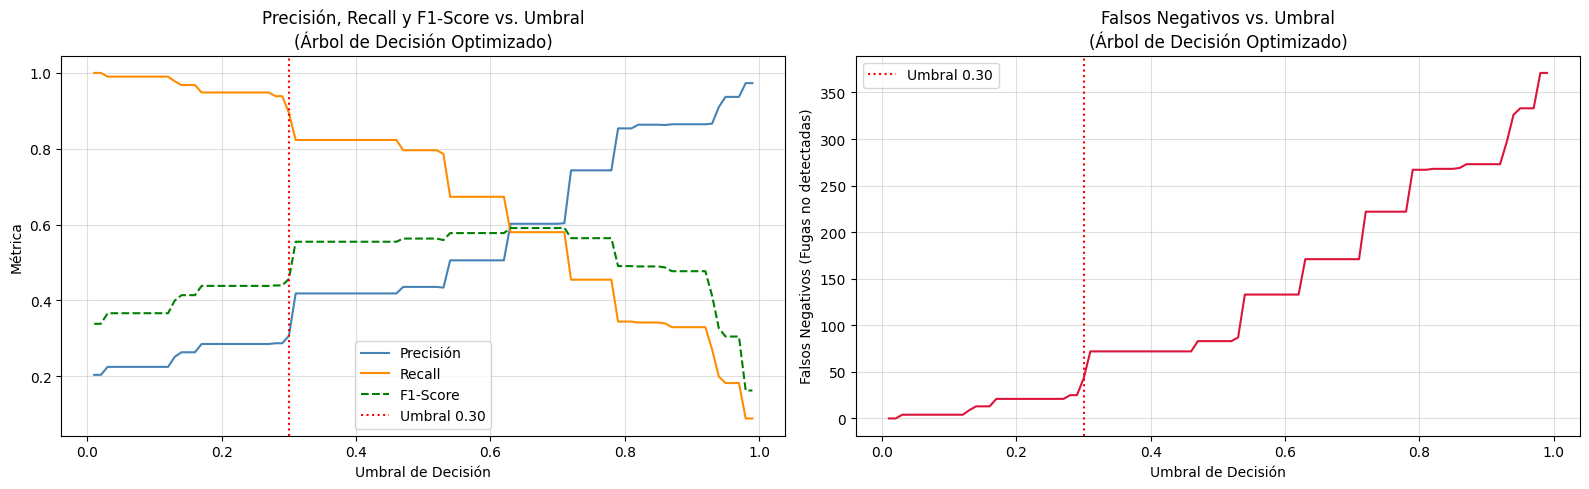

,Umbral,Precisión (Clase 1),Recall (Clase 1),F1-Score (Clase 1),Falsos Negativos,Falsos Positivos
0,0.20,0.2849,0.9484,0.4381,21,969
1,0.25,0.2849,0.9484,0.4381,21,969
2,0.30,0.3067,0.8943,0.4567,43,823
3,0.35,0.4182,0.8231,0.5546,72,466
4,0.40,0.4182,0.8231,0.5546,72,466
5,0.50,0.4355,0.7961,0.5630,83,420



EVALUACIÓN FINAL — Umbral Óptimo = 0.3
              precision    recall  f1-score   support

    No Churn       0.95      0.48      0.64      1593
       Churn       0.31      0.89      0.46       407

    accuracy                           0.57      2000
   macro avg       0.63      0.69      0.55      2000
weighted avg       0.82      0.57      0.60      2000



,Predicted No Churn,Predicted Churn
Actual No Churn,770,823
Actual Churn,43,364



ROC-AUC Score: 0.8416
Falsos Negativos (fugas no detectadas): 43
Falsos Positivos (alertas falsas):      823


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve, roc_curve, roc_auc_score,
    f1_score, precision_score, recall_score, confusion_matrix,
    classification_report
)
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# --- Carga y preprocesamiento de datos (duplicado para hacer la celda autocontenida) ---
# Cargar datos (from cell 50262e55)
path = 'https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/projects/data/bank.csv'
df = pd.read_csv(path, sep="," )

# Preprocesamiento de datos (from cell 81f85382)
df_bank = df.copy()
df_bank = df_bank.drop('customer_id', axis=1)
df_bank['gender'] = df_bank['gender'].map({'Female': 0, 'Male': 1})
df_bank = pd.get_dummies(df_bank, columns=['country'], drop_first=True, dtype=int)
numeric_cols_to_scale = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary', 'products_number']
scaler = StandardScaler()
df_bank[numeric_cols_to_scale] = scaler.fit_transform(df_bank[numeric_cols_to_scale])

# División de datos (from cell 5847c00b)
X = df_bank.drop('churn', axis=1)
y = df_bank['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Entrenamiento del mejor modelo de Árbol de Decisión Optimizado (duplicado de cell cf3989fc)
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}
dt_base = DecisionTreeClassifier(random_state=42, class_weight='balanced')
grid_search_dt = GridSearchCV(estimator=dt_base,
                              param_grid=param_grid_dt,
                              scoring='roc_auc',
                              cv=5,
                              n_jobs=-1,
                              verbose=0) # Set verbose to 0 to reduce output
grid_search_dt.fit(X_train, y_train)
best_dt_model = grid_search_dt.best_estimator_
y_pred_best_dt = best_dt_model.predict(X_test)
y_prob_best_dt = best_dt_model.predict_proba(X_test)[:, 1]

# ─── Usamos el mejor modelo: Árbol de Decisión Optimizado ───
# Probabilidades ya calculadas: y_prob_best_dt, y_test

thresholds_range = np.arange(0.01, 1.0, 0.01)

precision_list, recall_list, f1_list, fn_list = [], [], [], []

for t in thresholds_range:
    y_pred_t = (y_prob_best_dt >= t).astype(int)
    precision_list.append(precision_score(y_test, y_pred_t, zero_division=0))
    recall_list.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1_list.append(f1_score(y_test, y_pred_t, zero_division=0))
    cm = confusion_matrix(y_test, y_pred_t)
    fn_list.append(cm[1, 0] if cm.shape == (2, 2) else 0)

# ─── 1. Gráfico: Precision, Recall y F1 vs. Umbral ───
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(thresholds_range, precision_list, label='Precisión', color='steelblue')
axes[0].plot(thresholds_range, recall_list, label='Recall', color='darkorange')
axes[0].plot(thresholds_range, f1_list, label='F1-Score', color='green', linestyle='--')
axes[0].axvline(x=0.3, color='red', linestyle=':', label='Umbral 0.30')
axes[0].set_xlabel('Umbral de Decisión')
axes[0].set_ylabel('Métrica')
axes[0].set_title('Precisión, Recall y F1-Score vs. Umbral\n(Árbol de Decisión Optimizado)')
axes[0].legend()
axes[0].grid(alpha=0.4)

# ─── 2. Gráfico: Falsos Negativos vs. Umbral ───
axes[1].plot(thresholds_range, fn_list, color='crimson')
axes[1].axvline(x=0.3, color='red', linestyle=':', label='Umbral 0.30')
axes[1].set_xlabel('Umbral de Decisión')
axes[1].set_ylabel('Falsos Negativos (Fugas no detectadas)')
axes[1].set_title('Falsos Negativos vs. Umbral\n(Árbol de Decisión Optimizado)')
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.show()

# ─── 3. Tabla resumen en umbrales clave ───
key_thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.5]
rows = []
for t in key_thresholds:
    y_pred_t = (y_prob_best_dt >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    rows.append({
        'Umbral': t,
        'Precisión (Clase 1)': round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        'Recall (Clase 1)': round(recall_score(y_test, y_pred_t, zero_division=0), 4),
        'F1-Score (Clase 1)': round(f1_score(y_test, y_pred_t, zero_division=0), 4),
        'Falsos Negativos': cm[1, 0] if cm.shape == (2, 2) else 0,
        'Falsos Positivos': cm[0, 1] if cm.shape == (2, 2) else 0,
    })

df_thresholds = pd.DataFrame(rows)
display(df_thresholds)

# ─── 4. Evaluación con el umbral óptimo seleccionado: 0.30 ───
UMBRAL_OPTIMO = 0.30
y_pred_optimo = (y_prob_best_dt >= UMBRAL_OPTIMO).astype(int)

print(f"\n{'='*60}")
print(f"EVALUACIÓN FINAL — Umbral Óptimo = {UMBRAL_OPTIMO}")
print(f"{'='*60}")
print(classification_report(y_test, y_pred_optimo, target_names=['No Churn', 'Churn']))

cm_opt = confusion_matrix(y_test, y_pred_optimo)
display(pd.DataFrame(cm_opt,
                     index=['Actual No Churn', 'Actual Churn'],
                     columns=['Predicted No Churn', 'Predicted Churn']))

print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_prob_best_dt):.4f}")
print(f"Falsos Negativos (fugas no detectadas): {cm_opt[1, 0]}")
print(f"Falsos Positivos (alertas falsas):      {cm_opt[0, 1]}")

# Optimización del umbral de decisión y análisis de negocio

En los modelos predictivos institucionales, el umbral por defecto de 0.5 rara vez representa el óptimo económico. A continuación, se evalúa el comportamiento de nuestro modelo ganador (**árbol de decisión optimizado**) bajo diferentes escenarios de sensibilidad para determinar el umbral óptimo de operación para **ABC Bank**.


## 1. Comparativa de desempeño bajo distintos umbrales

*   **Escenario de alta sensibilidad (umbrales 0.20 - 0.25):**
    En este extremo, el modelo minimiza las fugas ciegas de manera casi perfecta (solo 21 Falsos Negativos) y alcanza un Recall masivo del 94.8%. Sin embargo, genera un colapso operativo con **969 Falsos Positivos**. Esto implicaría levantar falsas alarmas inundando los canales de atención.
*   **Escenario estándar de la industria (umbral 0.50):**
    Al operar con el parámetro por defecto de $0.50$, la Precisión se sitúa en 43.5% y el Recall en 79.6%, dejando escapar a **83 clientes** (Falsos Negativos). Es un rendimiento aceptable, pero subóptimo si la prioridad corporativa es blindar la cartera transaccional.
*   **El punto de quiebre estratégico (Umbral 0.30):**
    Al reducir el umbral a $0.30$, se genera una optimización asimétrica crítica. Como se observa en las curvas de rendimiento, el **Recall salta con fuerza al 89.43%**, permitiendo al banco capturar de forma proactiva a casi 9 de cada 10 clientes en riesgo de abandono.


## 2. Determinación del umbral de decisión óptimo

> Se ratifica el **umbral de 0.30** como la frontera operativa óptima para ABC Bank.

### Justificación técnica y operativa:
Si observamos el gráfico de *Falsos Negativos vs. Umbral*, el valor de $0.30$ se ubica justo en el último escalón plano antes de que las fugas no detectadas se disparen de forma vertical.
Al fijar la operación en 0.30, **reducimos las fugas ciegas de 83 (en el umbral 0.50) a solo 43 clientes**. Pagamos este beneficio con un incremento controlado de Falsos Positivos (de 420 a 823), lo cual es manejable mediante estrategias de marketing automatizado sin saturar a la fuerza de venta.


## 3. Dimensión de negocio: ¿es más importante maximizar el Recall o la Precisión para ABC Bank?

Para **ABC Bank**, la respuesta estratégica óptima es **maximizar el RECALL**, y la justificación económica se fundamenta en la profunda **asimetría de costos** que caracteriza a la industria bancaria actual.

### Sustentación económica y comercial de la decisión:

1. **El costo catastrófico del falso negativo (mano de obra del recall):**
   Dejar que un cliente real en riesgo de *churn* pase desapercibido (Falso negativo) tiene un costo financiero altísimo. ABC Bank pierde el margen de interés neto de sus productos, las comisiones por uso de tarjetas y el saldo total de los depósitos bajo gestión. Peor aún, el costo de adquisición de clientes (CAC) en la banca corporativa y de personas es sumamente elevado; reconquistar o salir a buscar un cliente nuevo que reemplace al que se fugó cuesta hasta **5 a 7 veces más** que retener al que ya confía en la institución. Por ende, un Recall alto del **89.43%** blinda el patrimonio del banco.

2. **El costo controlable del falso positivo (mano de obra de la precisión):**
   Clasificar por error a un cliente estable como "en riesgo de fuga" (Falsos Positivos = 823) tradicionalmente se consideraba un desperdicio de presupuesto. Sin embargo, en la era de la transformación digital, las acciones de retención no requieren necesariamente regalar dinero o regalar tasas preferenciales de manera física.
   
   **Estrategia de mitigación del gasto:** ABC Bank puede absorber esos 823 Falsos Positivos implementando una **campaña de fidelización blanda y automatizada**. En lugar de un costoso llamado telefónico individual, estos clientes reciben:
   * correos con contenido personalizado,
   * notificaciones push con invitaciones a programas de beneficios, o
   * encuestas de satisfacción automatizadas.

Para el cliente estable que fue etiquetado por error, la acción no se percibe como un incentivo innecesario, sino como un **excelente servicio al cliente** que mejora el Net Promoter Score (NPS) institucional. Mientras tanto, para los clientes que efectivamente pensaban irse, la campaña actúa como el freno de contención perfecto.

###Conclusión:
Maximizar el **Recall** mediante el umbral de **0.30** es la decisión que resguarda de mejor manera el valor del ciclo de vida del cliente (*Customer Lifetime Value*) y la estabilidad financiera de ABC Bank.



### 7. Análisis de Negocio y Recomendaciones

Una vez que el modelo identifique las características más relevantes:

- Discuta qué factores influyen más fuertemente en el *churn* (p.ej., bajo puntaje crediticio, saldo alto pero cliente inactivo).
- Proponga **acciones concretas** para cada factor clave.
  - *Ejemplo:* Ofrecer incentivos personalizados a clientes inactivos de alto valor.
  - *Ejemplo:* Revisar precios o beneficios para clientes con alta probabilidad de *churn* en ciertos países.

Considere también:
- ¿Qué podría hacer el banco el próximo trimestre para **reducir el *churn* en un 10%**?
- ¿Cómo podría este modelo **integrarse en una campaña de retención de clientes**?



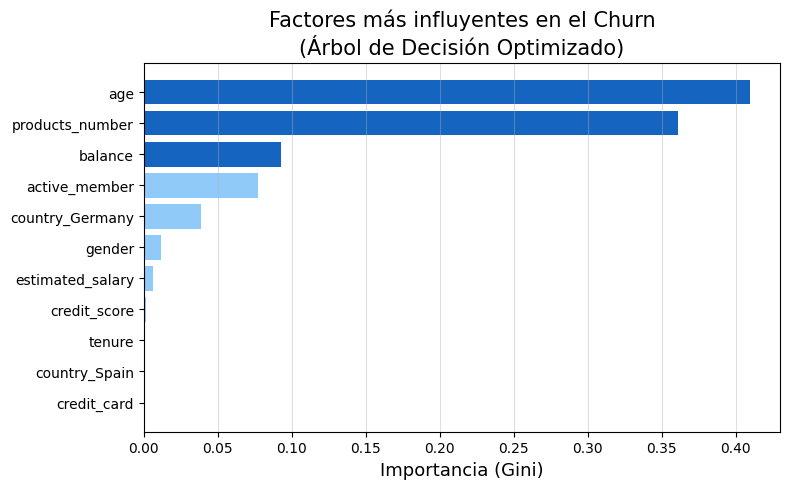

Top 5 factores predictores de Churn:


,Variable,Importancia
2,age,0.409555
5,products_number,0.361361
4,balance,0.092952
7,active_member,0.077425
9,country_Germany,0.038772


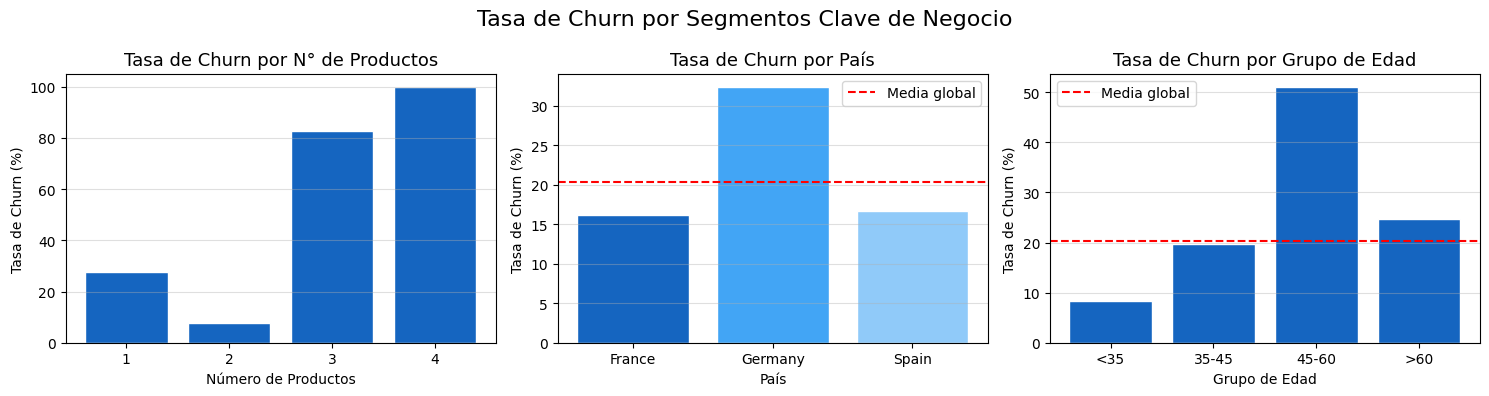

,Factor de Riesgo,Hallazgo,Acción Recomendada,Impacto Estimado
0,Edad 45-60 años,Clientes de mediana edad tienen la mayor tasa ...,Asignar ejecutivo personal dedicado; ofrecer b...,Alto: segmento con mayor pérdida de patrimonio...
1,3 o 4 Productos Contratados,Tasa de fuga casi total (>80%) con 3-4 productos,Revisión de la estrategia de cross-selling; si...,Alto: eliminar fricción reduce fuga drásticamente
2,País: Alemania,"Tasa de churn ~32%, duplica la media global",Campaña de retención localizada en Alemania; a...,Medio-Alto: mercado con mayor tasa de deserción
3,Miembro Inactivo,Los inactivos abandonan significativamente más,"Programa de reactivación: contacto proactivo, ...",Medio: campaña digital de bajo costo y alto al...
4,Saldo alto + inactividad,Clientes con saldo > mediana que no transaccionan,Alerta de riesgo en CRM; oferta de inversión o...,Alto: retener capital bajo gestión protege el ...


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Re-execute necessary data loading and preprocessing steps ---
# From cell 50262e55: Load data
path = 'https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/projects/data/bank.csv'
df = pd.read_csv(path, sep="," )

# From cell 81f85382: Preprocessing
from sklearn.preprocessing import StandardScaler
df_bank = df.copy()
df_bank = df_bank.drop('customer_id', axis=1)
df_bank['gender'] = df_bank['gender'].map({'Female': 0, 'Male': 1})
df_bank = pd.get_dummies(df_bank, columns=['country'], drop_first=True, dtype=int)
numeric_cols_to_scale = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary', 'products_number']
scaler = StandardScaler()
df_bank[numeric_cols_to_scale] = scaler.fit_transform(df_bank[numeric_cols_to_scale])

# From cell 5847c00b: Split data
from sklearn.model_selection import train_test_split
X = df_bank.drop('churn', axis=1)
y = df_bank['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# From cell cf3989fc: Train best_dt_model
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}
dt_base = DecisionTreeClassifier(random_state=42, class_weight='balanced')
grid_search_dt = GridSearchCV(estimator=dt_base,
                              param_grid=param_grid_dt,
                              scoring='roc_auc',
                              cv=5,
                              n_jobs=-1,
                              verbose=0)
grid_search_dt.fit(X_train, y_train)
best_dt_model = grid_search_dt.best_estimator_

# --- Original plotting code (with previous figsize adjustments and corrected characters) ---

# ─── 1. Importancia de Variables (Feature Importance) ───
feature_names = X_train.columns.tolist()
importances = best_dt_model.feature_importances_

feat_df = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': importances
}).sort_values('Importancia', ascending=True)

plt.figure(figsize=(8, 5))
colors = ['#1565C0' if imp >= feat_df['Importancia'].quantile(0.75) else '#90CAF9'
          for imp in feat_df['Importancia']]
plt.barh(feat_df['Variable'], feat_df['Importancia'], color=colors)
plt.xlabel('Importancia (Gini)', fontsize=13)
plt.title('Factores más influyentes en el Churn\n(Árbol de Decisión Optimizado)', fontsize=15)
plt.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

# ─── 2. Top 5 variables más importantes ───
top5 = feat_df.sort_values('Importancia', ascending=False).head(5)
print("Top 5 factores predictores de Churn:")
display(top5)

# ─── 3. Tasa de Churn real por segmentos clave del negocio ───
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Tasa de Churn por Segmentos Clave de Negocio', fontsize=16)

# Por número de productos
churn_prod = df.groupby('products_number')['churn'].mean().reset_index()
axes[0].bar(churn_prod['products_number'].astype(str),
            churn_prod['churn'] * 100, color='#1565C0', edgecolor='white')
axes[0].set_title('Tasa de Churn por N° de Productos', fontsize=13)
axes[0].set_xlabel('Número de Productos')
axes[0].set_ylabel('Tasa de Churn (%)')
axes[0].grid(axis='y', alpha=0.4)

# Por país
churn_country = df.groupby('country')['churn'].mean().reset_index()
axes[1].bar(churn_country['country'], churn_country['churn'] * 100,
            color=['#1565C0', '#42A5F5', '#90CAF9'], edgecolor='white')
axes[1].set_title('Tasa de Churn por País', fontsize=13)
axes[1].set_xlabel('País')
axes[1].set_ylabel('Tasa de Churn (%)')
axes[1].axhline(y=df['churn'].mean() * 100, color='red', linestyle='--', label='Media global')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.4)

# Por membresía activa y grupo de edad
df['age_group'] = pd.cut(df['age'], bins=[0, 35, 45, 60, 100],
                          labels=['<35', '35-45', '45-60', '>60'])
churn_age = df.groupby('age_group', observed=True)['churn'].mean().reset_index()
axes[2].bar(churn_age['age_group'].astype(str), churn_age['churn'] * 100,
            color='#1565C0', edgecolor='white')
axes[2].set_title('Tasa de Churn por Grupo de Edad', fontsize=13)
axes[2].set_xlabel('Grupo de Edad')
axes[2].set_ylabel('Tasa de Churn (%)')
axes[2].axhline(y=df['churn'].mean() * 100, color='red', linestyle='--', label='Media global')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

# ─── 4. Plan de acción estratégico ───
plan = {
    'Factor de Riesgo': [
        'Edad 45-60 años',
        '3 o 4 Productos Contratados',
        'País: Alemania',
        'Miembro Inactivo',
        'Saldo alto + inactividad'
    ],
    'Hallazgo': [
        'Clientes de mediana edad tienen la mayor tasa de churn (~40%)',
        'Tasa de fuga casi total (>80%) con 3-4 productos',
        'Tasa de churn ~32%, duplica la media global',
        'Los inactivos abandonan significativamente más',
        'Clientes con saldo > mediana que no transaccionan'
    ],
    'Acción Recomendada': [
        'Asignar ejecutivo personal dedicado; ofrecer beneficios de fidelización premium (tasas preferenciales, seguro gratuito)',
        'Revisión de la estrategia de cross-selling; simplificar contratos y ofrecer producto bundle con descuento',
        'Campaña de retención localizada en Alemania; auditoría de precios y servicio vs. competencia local',
        'Programa de reactivación: contacto proactivo, oferta de producto digital o cashback por uso de la app',
        'Alerta de riesgo en CRM; oferta de inversión o plazo fijo para "activar" el saldo dormido'
    ],
    'Impacto Estimado': [
        'Alto: segmento con mayor pérdida de patrimonio gestionado',
        'Alto: eliminar fricción reduce fuga drásticamente',
        'Medio-Alto: mercado con mayor tasa de deserción',
        'Medio: campaña digital de bajo costo y alto alcance',
        'Alto: retener capital bajo gestión protege el margen del banco'
    ]
}

df_plan = pd.DataFrame(plan)
display(df_plan)

# Diagnóstico de Factores Críticos y Plan de Acción Comercial

Una vez determinado el umbral operativo óptimo, utilizamos la capacidad del **Árbol de Decisión Optimizado** para extraer la importancia de las variables computacionales y cruzarla con el comportamiento empírico de la cartera. Esto nos permite diseñar una estrategia de contención con un enfoque puramente financiero y operativo para **ABC Bank**.

---

## 1. Discusión de los factores más influyentes en el Churn

Basado en el gráfico de *Feature Importance* y la segmentación real de las tasas de deserción, identificamos las dinámicas críticas que amenazan la estabilidad del banco:

1. **El factor demográfico crítico (edad):**
   La variable **age** es el predictor más fuerte del modelo con un **40.95% de importancia**. Al mirar la distribución, el grupo de **45-60 años** rompe la media global de manera alarmante, superando el **50% de tasa de churn**. Este hallazgo es un golpe directo a la línea de flotación del banco: se están fugando los clientes en su etapa de mayor madurez financiera y capacidad de ahorro, lo que drena masivamente los fondos bajo gestión.
2. **La crisis del multi-producto (número de Productos):**
   Con un **36.14% de importancia**, la variable **products_number** es el segundo pilar del modelo. El análisis descriptivo revela un comportamiento crítico: mientras que los clientes con 2 productos son los más estables, **aquellos con 3 productos superan el 80% de churn, y los de 4 productos alcanzan una tasa de fuga del 100%**. Esto demuestra una severa falla operativa; el proceso de venta cruzada (*cross-selling*) del banco está sobrecargando al cliente con fricciones (comisiones cruzadas, cobros confusos o mala experiencia), empujándolo a una deserción garantizada.
3. **El riesgo geográfico en Alemania:**
   La variable **country_Germany** tiene un peso relevante en el árbol. Como se observa en el gráfico, la operación en **Alemania registra un churn de ~32%**, duplicando holgadamente la media global de la muestra. Esto evidencia una pérdida de competitividad en la plaza europea, lo que podría estar basado en una oferta local rígida ante el avance de los neobancos.
4. **Desconexión comercial (miembros inactivos con saldo alto):**
   La inactividad (**active_member** con 7.74%) combinada con el volumen de fondos (**balance** con 9.29%) confirma la presencia de cuentas "dormidas". Clientes que mantienen capital líquido en el banco pero no transaccionan representan un riesgo inminente: están a solo un clic de distancia de transferir todo su patrimonio a otra entidad que les ofrezca una mejor tasa o experiencia digital.


### 2. Plan de acción inmediato: reducción del Churn en 10% para el próximo trimestre

Para cumplir con la meta corporativa de **reducir el churn en un 10%** durante los próximos 90 días, ABC Bank ejecutará un plan de choque enfocado en mitigar los dolores detectados en las métricas analizadas:

*   **Segmento Adulto (45-60 años) — Plan escudo preferencial**
    *   **Hallazgo del modelo:** Este grupo registra un Churn $>50\%$ según los datos de la cartera. Es críticamente el segmento de mayor valor y madurez patrimonial del banco.
    *   **Acción concreta e inmediata:** Asignación automática de un ejecutivo dedicado para rediseñar su experiencia financiera. Se les ofrecerán tasas de captación preferenciales en Depósitos a Plazo (DAP) y seguros de salud o vida con costo cero para amarrar la cuenta.
    *   **Canal de implementación:** Contacto telefónico e individual prioritario por parte de ejecutivos senior de Alta Fidelidad.


*   **Clientes con 3-4 productos contratados — campaña unificación de cuentas**
    *   **Hallazgo del modelo:** El churn se dispara de forma dramática del $80\%$ al $100\%$, lo que delata una severa fricción operativa y sobreventa de productos que ahoga al usuario.
    *   **Acción concreta e inmediata:** Auditar estas cuentas de manera urgente mediante sistemas centralizados, congelar el cobro de comisiones de mantención por un periodo de 6 meses y consolidar todos sus productos en un *bundle* único 100% digital con tarifa plana transparente.
    *   **Canal de implementación:** Alerta pop-up inmediata en el CRM al momento en que el cliente sea atendido en sucursal y envío de correo masivo personalizado desde la Gerencia de Clientes.


*   **Mercado local en Alemania — campaña de nivelación competitiva**
    *   **Hallazgo del modelo:** La operación en Alemania presenta una tasa de abandono del 32%, duplicando holgadamente la media global del portafolio.
    *   **Acción concreta e inmediata:** Lanzar una revisión profunda de precios, tasas y beneficios localizada exclusivamente en el mercado alemán. Se introducirán beneficios transaccionales digitales competitivos frente a los neobancos locales, tales como transferencias internacionales gratuitas o programas de cashback transaccional.
    *   **Canal de implementación:** Campañas de marketing digital altamente segmentadas por geolocalización.


*   **Miembros inactivos con saldo alto — campaña activa tus fondos**
    *   **Hallazgo del modelo:** Representa capital inmovilizado y pasivo que se encuentra en un riesgo inminente de migración rápida hacia la competencia por falta de uso de la cuenta.
    *   **Acción concreta e inmediata:** Diseñar y despachar ofertas personalizadas y automatizadas de inversión para incentivar a los clientes a mover esos saldos ociosos hacia Fondos Mutuos de liquidez inmediata o productos de inversión de corto plazo con un premio de tasa de interés atractiva.
    *   **Canal de implementación:** Envío de notificaciones *Push* automatizadas dentro de la App Móvil institucional y banners destacados al iniciar sesión en la Web.


## Integración del modelo predictivo en la campaña de retención (CRM)

Para transformar este modelo en un motor continuo de generación de valor, su despliegue se integrará de forma automatizada en el ecosistema **CRM** de ABC Bank mediante tres pilares operativos:

1. **Puntuación diaria en lote (*Batch Scoring*):**
   Cada noche, el CRM alimentará al modelo con los datos actualizados de transaccionalidad, edad, saldo y tenencia de productos de toda la cartera. El árbol optimizado evaluará los registros y asignará a cada cliente una probabilidad de fuga utilizando nuestro **umbral de 0.30**.
2. **Gatillos automáticos de atención (Triggers de alerta temprana):**
   * **Score $\ge 0.30$ (riesgo de fuga mayor o igual a 30%):** El CRM encenderá una bandera de alerta en la ficha del cliente. Si el usuario ingresa al portal web, llama al *Call Center* o asiste a una sucursal, el sistema forzará un protocolo de atención preferencial, bloqueando la venta cruzada agresiva para no generar más fricción.
   * **Score $\ge 0.50$:** El sistema disparará una orden de trabajo automatizada con prioridad alta al ejecutivo a cargo para realizar una llamada de fidelización e identificar el descontento en menos de 24 horas.
3. **Eficiencia presupuestaria en marketing:**
   En lugar de malgastar el presupuesto de retención de forma masiva en clientes que no piensan irse, el modelo permite hacer una asignación quirúrgica del capital. Las campañas digitales automatizadas de costo cero (correos y notificaciones) se usarán para los segmentos de riesgo bajo/moderado, mientras que los incentivos financieros fuertes (descuentos en tasas o exoneración de cobros) se reservarán exclusivamente para los clientes de alto valor que el modelo detectó al borde de la deserción.



## Entregables

Cada estudiante o grupo debe presentar los siguientes materiales:

| # | Entregable | Descripción |
|---|---|---|
| 1 | **Jupyter Notebook** (`.ipynb`) | Análisis completo con razonamiento y todas las visualizaciones. Debe incluir justificaciones claras para las decisiones de preprocesamiento, tratamiento de valores atípicos, imputación de faltantes y elección de modelos. Finaliza con conclusiones orientadas al negocio y recomendaciones basadas en datos. |
| 2 | **Resumen Ejecutivo** (1–2 párrafos) | Síntesis concisa de los hallazgos principales: modelo seleccionado, justificación de la elección y recomendaciones claras para la dirección de ABC Bank. |
| 3 | **Presentación Oral** (12–15 minutos) | Ver rúbrica de evaluación más abajo. |

La presentación debe incluir:

- El problema de negocio y el objetivo del proyecto.
- Hallazgos clave del análisis exploratorio.
- Comparación de modelos y resultados.
- Umbral seleccionado e interpretación de las métricas.
- Implicaciones para el negocio y acciones recomendadas.

Se recomienda el uso de visualizaciones (gráficos, tablas, dashboards) para hacer la presentación más clara y atractiva.

> ⚠️ **Importante:** La nota final del proyecto se basa en **ambos componentes**: el informe escrito (Notebook + Resumen Ejecutivo) y la presentación oral. Si un equipo entrega solo el informe sin presentar, o presenta sin haber entregado el informe, el proyecto recibirá la nota mínima. **Ambos componentes son obligatorios** y se evalúan de manera conjunta.



## Rúbrica de Presentación Oral

Cada grupo será evaluado en una escala de 10 a 100 puntos. Las presentaciones deben realizarse en español o inglés y tener una duración de entre **12 y 15 minutos**.

### Criterios de Evaluación

| Criterio | Descripción | Puntaje | Ponderación |
|---|---|---|---|
| **1. Comprensión del problema y contexto** | Demuestra comprensión clara del problema de negocio, la importancia de predecir el *churn* y el objetivo del proyecto. Vincula el trabajo de ciencia de datos con el impacto real en el negocio. | 10–20 pts | 20% |
| **2. Exploración de datos e insights** | Presenta los hallazgos del EDA de forma clara y concisa. Destaca patrones, tendencias o anomalías relevantes. Explica cómo el análisis orientó el desarrollo del modelo. | 10–20 pts | 20% |
| **3. Explicación y comparación de modelos** | Explica los modelos, la estrategia de ajuste y las métricas de desempeño (AUC, precisión, recall, etc.) con precisión. Muestra una comparación clara entre modelos y justifica la elección final. | 10–20 pts | 20% |
| **4. Interpretación de negocio y recomendaciones** | Traduce los resultados técnicos en insights accionables para el negocio. Explica qué debe hacer el banco con los resultados y cómo el modelo puede apoyar la toma de decisiones. | 10–20 pts | 20% |
| **5. Comunicación y presentación** | Comunicación clara y profesional en español o inglés. Flujo lógico, tono atractivo, pronunciación correcta y confianza. Trabajo en equipo efectivo y manejo adecuado del tiempo. | 10–15 pts | 15% |
| **6. Apoyos visuales y diseño de diapositivas** | Uso efectivo de diapositivas o dashboards. Las visualizaciones son claras, profesionales y facilitan la comprensión (gráficos, tablas, métricas clave). Evita diapositivas con exceso de texto o desorganizadas. | 10–15 pts | 15% |

### Escala de Calificación

| Puntaje | Nivel | Descripción |
|---|---|---|
| 90–100 | ⭐ Sobresaliente | Comprensión excepcional, comunicación impecable y vínculo sólido entre los datos y el negocio. Presentación atractiva e insightful. |
| 80–89 | ✅ Muy Bueno | Explicación clara y buen soporte visual, con brechas menores en profundidad o fluidez. Sólido dominio técnico y de negocio. |
| 70–79 | ⚙️ Bueno | Cubre los puntos principales de manera adecuada, pero con falta de profundidad o claridad en algunas áreas. Estructura y trabajo en equipo razonables. |
| 60–69 | ⚠️ Aceptable | Cobertura básica del proyecto con insight limitado o conexión débil con el problema de negocio. Presentación algo confusa o apresurada. |
| 10–59 | ❌ Insuficiente | Estructura deficiente, explicación poco clara, contenido incompleto o incapacidad para comunicar los hallazgos. Puede no respetar el tiempo o evidenciar falta de trabajo en equipo. |

### Notas para Evaluadores

- Descontar hasta **−10 puntos** si la presentación no se encuentra dentro del rango de tiempo permitido (menos de 8 min o más de 15 min).
- Descontar hasta **−5 puntos** si no todos los integrantes participan activamente.
- Otorgar hasta **+5 puntos de bonificación** por creatividad excepcional, claridad o insight de negocio relevante.

**Puntaje máximo:** 100 puntos | **Nota mínima de aprobación:** 60 puntos
